# Chặng 2 — Ai đã rời đi? & Mổ xẻ Thảm họa Khuyến mãi

**Giả thuyết cần kiểm chứng:**
}

**Outline:**
- **Phần 1:** Ai đã rời đi? → So sánh cơ cấu khách hàng & category giữa 2 giai đoạn
- **Phần 2:** Mổ xẻ Thảm họa Khuyến mãi → Lạm dụng, Lờn thuốc, Targeting sai lệch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
        {
            "cell_type": "code",
            "id": "#VSC-a4a574cd",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# =====================================================================",
                "# CELL C: PROMO PENETRATION — Tỷ lệ đơn có promo theo Category × Năm",
                "# =====================================================================",
                "import pandas as pd",
                "import numpy as np",
                "import matplotlib.pyplot as plt",
                "import seaborn as sns",
                "import matplotlib.ticker as mticker",
                "",
                "orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])",
                "order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')",
                "products = pd.read_csv(INPUT_DIR / 'products.csv')",
                "",
                "orders_delivered = orders[orders['order_status'] == 'delivered'].copy()",
                "orders_delivered['year'] = orders_delivered['order_date'].dt.year",
                "",
                "# Quy về cấp order-category-year: một order có thể xuất hiện ở nhiều category nếu chứa nhiều category khác nhau.",
                "# Promo penetration = số order có promo trong category / tổng số order có category theo năm.",
                "items_pen = (",
                "    order_items",
                "    .merge(orders_delivered[['order_id', 'order_date', 'year']], on='order_id', how='inner')",
                "    .merge(products[['product_id', 'category']], on='product_id', how='left')",
                ")",
                "items_pen['has_promo'] = ((items_pen['discount_amount'].fillna(0) > 0) | (items_pen['promo_id'].notna())).astype(int)",
                "",
                "order_cat_level = (",
                "    items_pen",
                "    .groupby(['order_id', 'year', 'category'])",
                "    .agg(promo_order=('has_promo', 'max'))",
                "    .reset_index()",
                ")",
                "",
                "penetration_cat_year = (",
                "    order_cat_level",
                "    .groupby(['year', 'category'])",
                "    .agg(",
                "        total_orders=('order_id', 'nunique'),",
                "        promo_orders=('promo_order', 'sum')",
                "    )",
                "    .reset_index()",
                ")",
                "penetration_cat_year['promo_penetration_pct'] = np.where(",
                "    penetration_cat_year['total_orders'] > 0,",
                "    penetration_cat_year['promo_orders'] / penetration_cat_year['total_orders'] * 100,",
                "    0",
                ")",
                "",
                "penetration_pivot = penetration_cat_year.pivot(index='year', columns='category', values='promo_penetration_pct').fillna(0)",
                "penetration_pivot = penetration_pivot.sort_index()",
                "",
                "print('Promo penetration by category and year:')",
                "print(penetration_cat_year.sort_values(['year', 'category']).to_string(index=False))",
                "",
                "fig, ax = plt.subplots(figsize=(13, 5.8))",
                "colors_map = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}",
                "",
                "for col in penetration_pivot.columns:",
                "    ax.plot(",
                "        penetration_pivot.index,",
                "        penetration_pivot[col],",
                "        color=colors_map.get(col, '#888780'),",
                "        linewidth=2.5 if col == 'Outdoor' else 1.8,",
                "        marker='o',",
                "        label=col",
                "    )",
                "",
                "ax.axvline(x=2018.5, color='#999', linestyle='--', linewidth=1.2)",
                "ax.text(2018.6, ax.get_ylim()[1] * 0.95, '← P1 | P2 →', fontsize=9, color='#666')",
                "",
                "ax.set_title('Promo Penetration theo Category × Năm\\n'",
                "             'Tỷ lệ order có promo trên tổng order của từng category', fontsize=13, fontweight='bold')",
                "ax.set_xlabel('Năm')",
                "ax.set_ylabel('% Order có Promo')",
                "ax.yaxis.set_major_formatter(mticker.PercentFormatter())",
                "ax.set_xticks(penetration_pivot.index)",
                "ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')",
                "",
                "plt.tight_layout()",
                "plt.show()"
            ]
        },
## 1.1 Cơ cấu khách hàng active theo `age_group`

✅ Setup OK — palette và style đã sẵn sàng


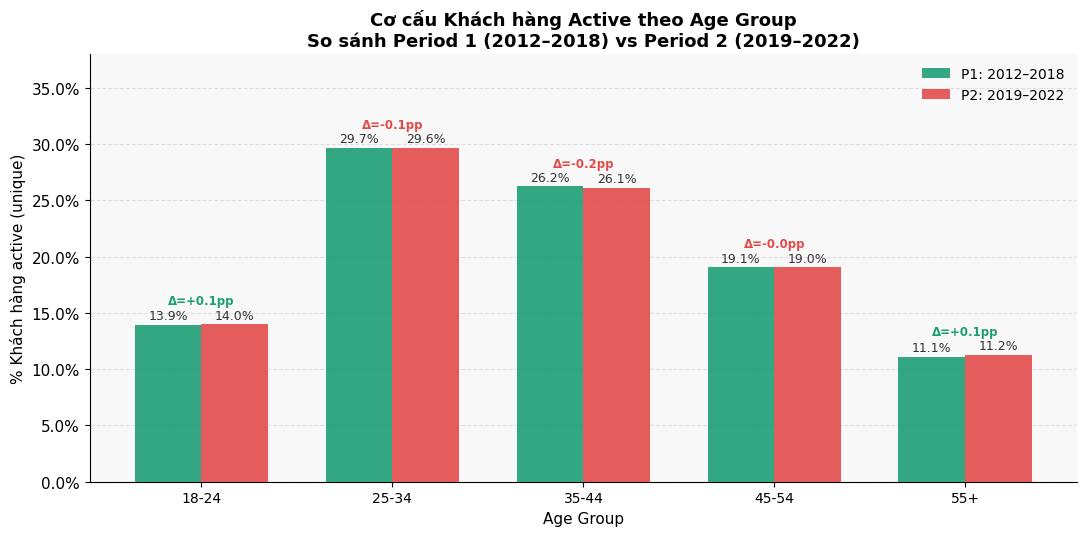

✅ Saved: output_1_1_age_group.png


In [7]:
# ── Đếm unique customer theo age_group × period ───────────────────────────
age_cust = (
    master
    .groupby(['period', 'age_group'])['customer_id']
    .nunique()
    .reset_index(name='n_customers')
)
age_cust['pct'] = (
    age_cust
    .groupby('period')['n_customers']
    .transform(lambda x: x / x.sum() * 100)
)

age_pivot = age_cust.pivot(index='age_group', columns='period', values='pct').fillna(0)

# Sort age_group theo thứ tự tự nhiên
try:
    age_order = sorted(
        age_pivot.index,
        key=lambda x: int(str(x).split('-')[0].replace('+','').replace('<','').strip())
    )
    age_pivot = age_pivot.loc[age_order]
except Exception:
    pass

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))

x      = np.arange(len(age_pivot.index))
width  = 0.35
cols   = age_pivot.columns.tolist()

bars1 = ax.bar(x - width/2, age_pivot[cols[0]], width, label=cols[0], color=C_P1, alpha=0.9, zorder=3)
bars2 = ax.bar(x + width/2, age_pivot[cols[1]], width, label=cols[1], color=C_P2, alpha=0.9, zorder=3)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.25,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#333')

for i, ag in enumerate(age_pivot.index):
    delta = age_pivot.loc[ag, cols[1]] - age_pivot.loc[ag, cols[0]]
    color = C_P2 if delta < 0 else C_P1
    ax.annotate(
        f'Δ={delta:+.1f}pp',
        xy=(i, max(age_pivot.loc[ag, cols[0]], age_pivot.loc[ag, cols[1]]) + 1.5),
        ha='center', va='bottom', fontsize=8.5, color=color, fontweight='bold'
    )

ymax = age_pivot.values.max()
ax.set_ylim(0, ymax * 1.28)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.set_xticks(x)
ax.set_xticklabels(age_pivot.index, fontsize=10)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('% Khách hàng active (unique)', fontsize=11)
ax.set_title('Cơ cấu Khách hàng Active theo Age Group\nSo sánh Period 1 (2012–2018) vs Period 2 (2019–2022)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()
print('✅ Saved: output_1_1_age_group.png')

## 1.2 Cơ cấu khách hàng active theo `region`

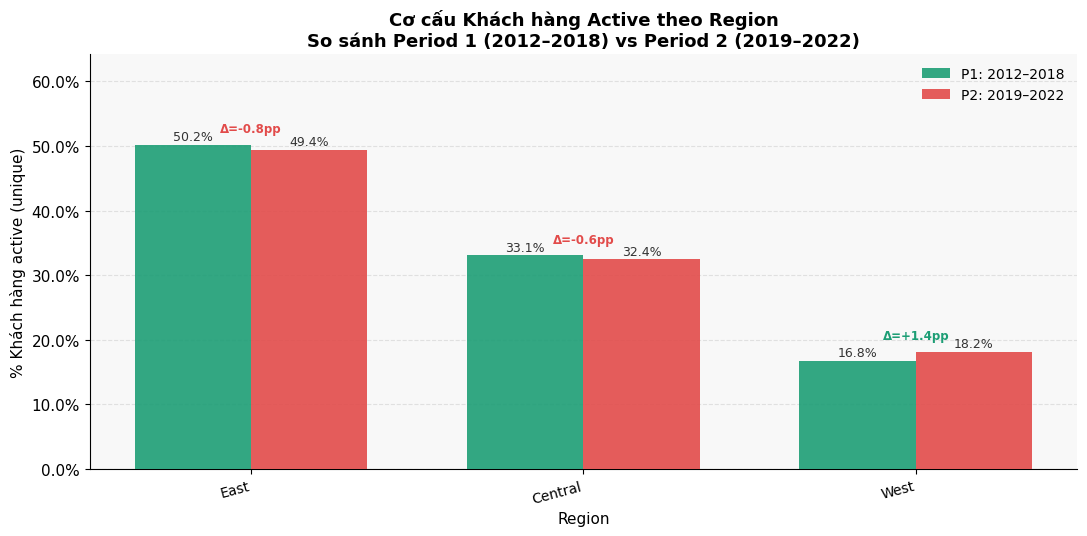

✅ Saved: output_1_2_region.png


In [8]:
# ── Đếm unique customer theo region × period ──────────────────────────────
region_cust = (
    master
    .groupby(['period', 'region'])['customer_id']
    .nunique()
    .reset_index(name='n_customers')
)
region_cust['pct'] = (
    region_cust
    .groupby('period')['n_customers']
    .transform(lambda x: x / x.sum() * 100)
)

# Sort region theo P1 descending
p1_label_r = [p for p in region_cust['period'].unique() if '2012' in p][0]
region_order = (
    region_cust[region_cust['period'] == p1_label_r]
    .sort_values('pct', ascending=False)['region'].tolist()
)

region_pivot = region_cust.pivot(index='region', columns='period', values='pct').fillna(0)
region_pivot = region_pivot.loc[[r for r in region_order if r in region_pivot.index]]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))

x     = np.arange(len(region_pivot.index))
width = 0.35
cols  = region_pivot.columns.tolist()

bars1 = ax.bar(x - width/2, region_pivot[cols[0]], width, label=cols[0], color=C_P1, alpha=0.9, zorder=3)
bars2 = ax.bar(x + width/2, region_pivot[cols[1]], width, label=cols[1], color=C_P2, alpha=0.9, zorder=3)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.25,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#333')

for i, rg in enumerate(region_pivot.index):
    delta = region_pivot.loc[rg, cols[1]] - region_pivot.loc[rg, cols[0]]
    color = C_P2 if delta < 0 else C_P1
    ax.annotate(
        f'Δ={delta:+.1f}pp',
        xy=(i, max(region_pivot.loc[rg, cols[0]], region_pivot.loc[rg, cols[1]]) + 1.5),
        ha='center', va='bottom', fontsize=8.5, color=color, fontweight='bold'
    )

ymax = region_pivot.values.max()
ax.set_ylim(0, ymax * 1.28)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.set_xticks(x)
ax.set_xticklabels(region_pivot.index, fontsize=10, rotation=15, ha='right')
ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('% Khách hàng active (unique)', fontsize=11)
ax.set_title('Cơ cấu Khách hàng Active theo Region\nSo sánh Period 1 (2012–2018) vs Period 2 (2019–2022)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()
print('✅ Saved: output_1_2_region.png')

## 1.3 Volume bán ra theo `category` — Category nào bốc hơi mạnh nhất?

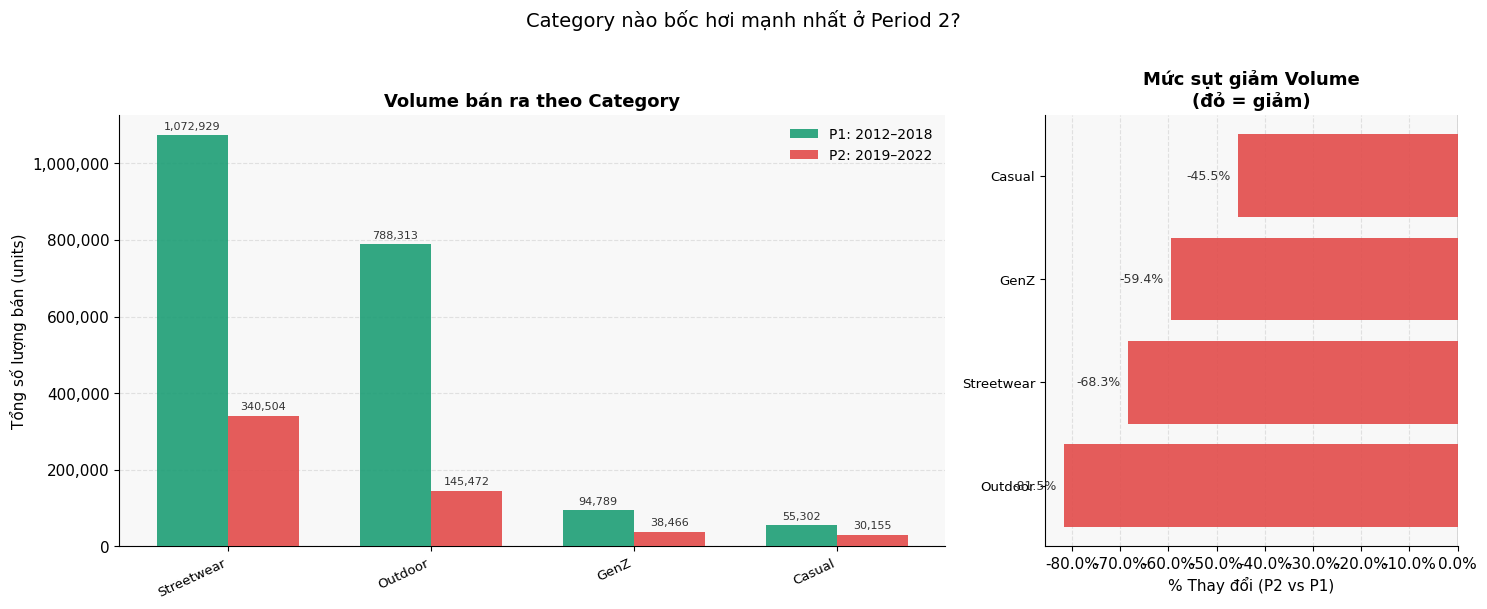


Top 3 category sụt giảm nhiều nhất:
category
Outdoor      -81.55
Streetwear   -68.26
GenZ         -59.42

✅ Saved: output_1_3_category_volume.png


In [9]:
# ── Join order_items ← orders (period) ← products (category) ──────────────
items_w_period = order_items.merge(
    orders_delivered[['order_id', 'period', 'year']],
    on='order_id', how='inner'
).merge(
    products[['product_id', 'category', 'segment']],
    on='product_id', how='left'
)

# Tổng quantity theo category × period
cat_vol = (
    items_w_period
    .groupby(['period', 'category'])['quantity']
    .sum()
    .reset_index(name='total_qty')
)

# Identify period labels
p1_label = [c for c in cat_vol['period'].unique() if '2012' in c][0]
p2_label = [c for c in cat_vol['period'].unique() if '2019' in c][0]

cat_pivot = cat_vol.pivot(index='category', columns='period', values='total_qty').fillna(0)
cat_pivot = cat_pivot.sort_values(p1_label, ascending=False)
cat_pivot['drop_pct'] = (cat_pivot[p2_label] - cat_pivot[p1_label]) / cat_pivot[p1_label].replace(0, np.nan) * 100

# ── Plot: Grouped bar + horizontal drop bar ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

# --- Subplot trái: Grouped bar volume tuyệt đối ---
ax = axes[0]
x     = np.arange(len(cat_pivot.index))
width = 0.35

bars1 = ax.bar(x - width/2, cat_pivot[p1_label], width, label=p1_label, color=C_P1, alpha=0.9, zorder=3)
bars2 = ax.bar(x + width/2, cat_pivot[p2_label], width, label=p2_label, color=C_P2, alpha=0.9, zorder=3)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                h + cat_pivot[p1_label].max() * 0.01,
                f'{h:,.0f}', ha='center', va='bottom', fontsize=8, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(cat_pivot.index, rotation=25, ha='right', fontsize=9.5)
ax.set_ylabel('Tổng số lượng bán (units)', fontsize=11)
ax.set_title('Volume bán ra theo Category', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=10)

# --- Subplot phải: % sụt giảm, horizontal bar ---
ax2 = axes[1]
cat_drop = cat_pivot['drop_pct'].dropna().sort_values(ascending=True)
colors_drop = [C_P2 if v < 0 else C_P1 for v in cat_drop.values]

ax2.barh(range(len(cat_drop)), cat_drop.values, color=colors_drop, alpha=0.9, zorder=3)
ax2.set_yticks(range(len(cat_drop)))
ax2.set_yticklabels(cat_drop.index, fontsize=9.5)
ax2.axvline(0, color='#555', linewidth=1)
ax2.set_xlabel('% Thay đổi (P2 vs P1)', fontsize=11)
ax2.set_title('Mức sụt giảm Volume\n(đỏ = giảm)', fontsize=13)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax2.grid(axis='x')
ax2.grid(axis='y', visible=False)

for i, v in enumerate(cat_drop.values):
    ax2.text(v + (abs(cat_drop.values).max() * 0.02 if v >= 0 else -abs(cat_drop.values).max() * 0.02),
             i, f'{v:+.1f}%', va='center',
             ha='left' if v >= 0 else 'right', fontsize=9, color='#333')

fig.suptitle('Category nào bốc hơi mạnh nhất ở Period 2?', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nTop 3 category sụt giảm nhiều nhất:')
print(cat_pivot['drop_pct'].sort_values().head(3).to_string())
print('\n✅ Saved: output_1_3_category_volume.png')

---
# PHẦN 2: MỔ XẺ THẢM HỌA KHUYẾN MÃI
## 2.1 Mức độ lạm dụng Promotion theo năm (2012–2022)

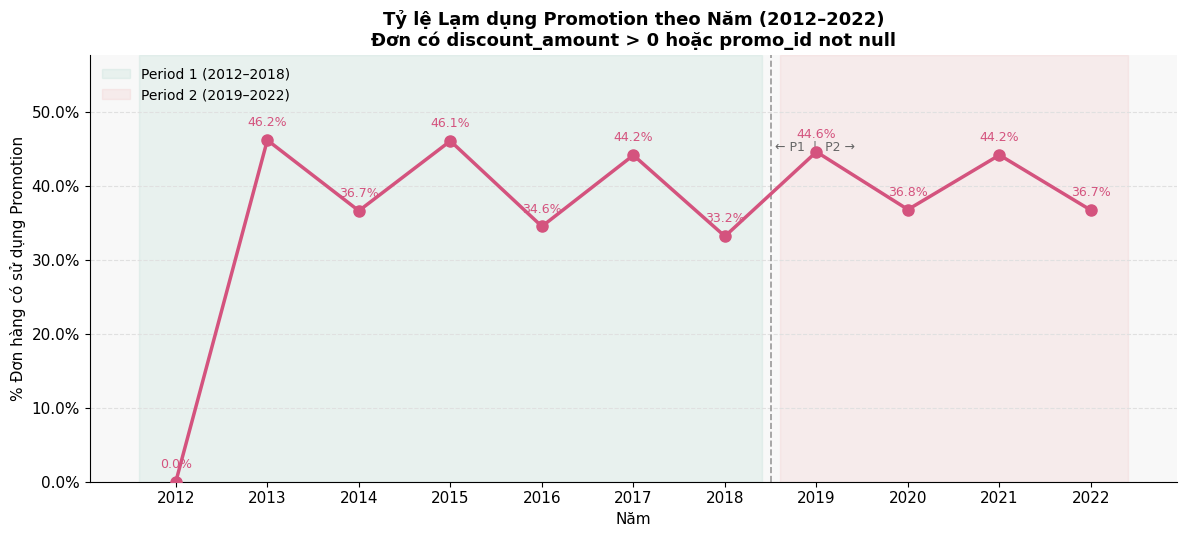

✅ Saved: output_2_1_promo_rate.png


In [10]:
# ── Join order_items với orders để lấy year & period ──────────────────────
items_all = order_items.merge(
    orders_delivered[['order_id', 'year', 'period', 'order_date']],
    on='order_id', how='inner'
)

# Đơn có promo = discount_amount > 0 HOẶC promo_id not null
items_all['has_promo'] = (
    (items_all['discount_amount'] > 0) |
    (items_all['promo_id'].notna())
).astype(int)

# Aggregate lên cấp order: has_promo = 1 nếu bất kỳ item nào có promo
promo_flag_per_order = (
    items_all
    .groupby(['order_id', 'year'])['has_promo']
    .max()
    .reset_index()
)

promo_by_year = (
    promo_flag_per_order
    .groupby('year')
    .agg(
        total_orders=('order_id', 'count'),
        promo_orders=('has_promo', 'sum')
    )
    .reset_index()
)
promo_by_year['promo_rate'] = promo_by_year['promo_orders'] / promo_by_year['total_orders'] * 100

# ── Plot: Line chart với shaded periods ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.axvspan(2012 - 0.4, 2018 + 0.4, alpha=0.07, color=C_P1, label='Period 1 (2012–2018)')
ax.axvspan(2019 - 0.4, 2022 + 0.4, alpha=0.07, color=C_P2, label='Period 2 (2019–2022)')

ax.plot(promo_by_year['year'], promo_by_year['promo_rate'],
        color=C_PROMO, linewidth=2.5, marker='o', markersize=8, zorder=4)

for _, row in promo_by_year.iterrows():
    ax.annotate(
        f"{row['promo_rate']:.1f}%",
        xy=(row['year'], row['promo_rate']),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=9, color=C_PROMO
    )

ax.axvline(x=2018.5, color='#999', linestyle='--', linewidth=1.2)
y_range = promo_by_year['promo_rate'].max() - promo_by_year['promo_rate'].min()
ax.text(2018.55, promo_by_year['promo_rate'].max() * 0.97,
        '← P1  |  P2 →', fontsize=9, color='#666')

ax.set_xticks(promo_by_year['year'])
ax.set_xlabel('Năm', fontsize=11)
ax.set_ylabel('% Đơn hàng có sử dụng Promotion', fontsize=11)
ax.set_title(
    'Tỷ lệ Lạm dụng Promotion theo Năm (2012–2022)\n'
    'Đơn có discount_amount > 0 hoặc promo_id not null', fontsize=13
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.legend(loc='upper left', fontsize=10)

y_min = promo_by_year['promo_rate'].min()
y_max = promo_by_year['promo_rate'].max()
ax.set_ylim(max(0, y_min - y_range * 0.25), y_max + y_range * 0.25)

plt.tight_layout()
plt.show()
print('✅ Saved: output_2_1_promo_rate.png')

## 2.2 Promo Fatigue — Scatter: % Discount trung bình vs Volume đơn theo tháng

In [11]:
# ── Tính gross value & discount % trên từng item ──────────────────────────
# Đảm bảo cột quantity tồn tại (order_items có quantity)
items_all['gross_item'] = items_all['unit_price'] * items_all['quantity']
items_all['discount_pct_item'] = np.where(
    items_all['gross_item'] > 0,
    items_all['discount_amount'] / items_all['gross_item'] * 100,
    0
)

# ── Tổng hợp lên cấp order ────────────────────────────────────────────────
order_level = (
    items_all
    .groupby(['order_id', 'year', 'order_date', 'period'])
    .agg(
        total_discount=('discount_amount', 'sum'),
        total_gross=('gross_item', 'sum')
    )
    .reset_index()
)
order_level['discount_pct_order'] = np.where(
    order_level['total_gross'] > 0,
    order_level['total_discount'] / order_level['total_gross'] * 100,
    0
)
order_level['ym'] = order_level['order_date'].dt.to_period('M')

# ── Aggregate theo tháng ──────────────────────────────────────────────────
monthly_promo = (
    order_level
    .groupby(['ym', 'period'])
    .agg(
        avg_discount_pct=('discount_pct_order', 'mean'),
        n_orders=('order_id', 'count')
    )
    .reset_index()
)
monthly_promo['ym_dt'] = monthly_promo['ym'].dt.to_timestamp()

print(f"Monthly records: {len(monthly_promo)}")
monthly_promo.head()

Monthly records: 126


,ym,period,avg_discount_pct,n_orders,ym_dt
0,2012-07,P1: 2012–2018,0.00,4233,2012-07-01
1,2012-08,P1: 2012–2018,0.00,5132,2012-08-01
2,2012-09,P1: 2012–2018,0.00,4202,2012-09-01
3,2012-10,P1: 2012–2018,0.00,3420,2012-10-01
4,2012-11,P1: 2012–2018,0.00,3279,2012-11-01


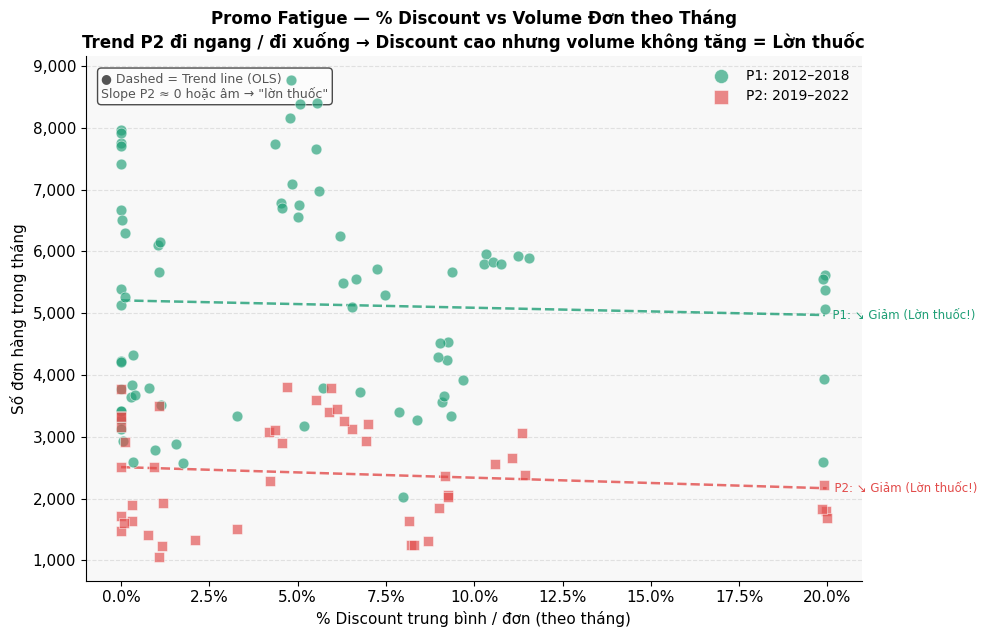

✅ Saved: output_2_2_promo_fatigue.png


In [12]:
# ── Scatter: avg_discount_pct vs n_orders, color theo Period ──────────────
fig, ax = plt.subplots(figsize=(10, 6.5))

period_styles = [
    ('P1: 2012–2018', C_P1, 'o'),
    ('P2: 2019–2022', C_P2, 's'),
]

for period, color, marker in period_styles:
    sub = monthly_promo[monthly_promo['period'] == period]
    ax.scatter(
        sub['avg_discount_pct'], sub['n_orders'],
        color=color, alpha=0.65, s=60, marker=marker,
        label=period, zorder=4, edgecolors='white', linewidths=0.5
    )
    # OLS trend line
    if len(sub) > 2:
        z  = np.polyfit(sub['avg_discount_pct'], sub['n_orders'], 1)
        p  = np.poly1d(z)
        xs = np.linspace(sub['avg_discount_pct'].min(), sub['avg_discount_pct'].max(), 100)
        ax.plot(xs, p(xs), color=color, linewidth=1.8, linestyle='--', alpha=0.8)
        # Annotate slope direction
        slope_sign = '↗ Tăng' if z[0] > 0 else '↘ Giảm (Lờn thuốc!)'
        ax.text(
            xs[-1], p(xs[-1]),
            f'  {period[:2]}: {slope_sign}',
            color=color, fontsize=8.5, va='center'
        )

ax.set_xlabel('% Discount trung bình / đơn (theo tháng)', fontsize=11)
ax.set_ylabel('Số đơn hàng trong tháng', fontsize=11)
ax.set_title(
    'Promo Fatigue — % Discount vs Volume Đơn theo Tháng\n'
    'Trend P2 đi ngang / đi xuống → Discount cao nhưng volume không tăng = Lờn thuốc',
    fontsize=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=10, markerscale=1.3)

ax.text(
    0.02, 0.97,
    '● Dashed = Trend line (OLS)\nSlope P2 ≈ 0 hoặc âm → "lờn thuốc"',
    transform=ax.transAxes, fontsize=9, va='top', color='#555',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
)

plt.tight_layout()
plt.show()
print('✅ Saved: output_2_2_promo_fatigue.png')

## 2.3 Targeting sai lệch — Tiền khuyến mãi chảy vào túi nhóm nào? (2019–2022)

In [13]:
# ── Lọc P2 & join products ────────────────────────────────────────────────
items_p2 = items_all[items_all['period'] == 'P2: 2019–2022'].copy()
items_p2 = items_p2.merge(
    products[['product_id', 'category', 'segment']],
    on='product_id', how='left'
)

# Tổng discount theo category
discount_by_cat = (
    items_p2
    .groupby('category')['discount_amount']
    .sum()
    .reset_index(name='total_discount')
    .sort_values('total_discount', ascending=False)
)
discount_by_cat['pct'] = discount_by_cat['total_discount'] / discount_by_cat['total_discount'].sum() * 100

# Tổng discount theo segment
discount_by_seg = (
    items_p2
    .groupby('segment')['discount_amount']
    .sum()
    .reset_index(name='total_discount')
    .sort_values('total_discount', ascending=False)
)
discount_by_seg['pct'] = discount_by_seg['total_discount'] / discount_by_seg['total_discount'].sum() * 100

print('Discount by Category (P2):')
print(discount_by_cat.to_string(index=False))
print('\nDiscount by Segment (P2):')
print(discount_by_seg.to_string(index=False))

Discount by Category (P2):
  category  total_discount   pct
Streetwear  132,493,244.89 80.20
   Outdoor   22,610,482.51 13.69
    Casual    6,357,673.50  3.85
      GenZ    3,740,296.19  2.26

Discount by Segment (P2):
    segment  total_discount   pct
   Balanced   70,270,339.01 42.54
   Everyday   39,114,593.86 23.68
Performance   20,258,706.48 12.26
 Activewear   17,892,889.28 10.83
All-weather    5,763,817.63  3.49
    Premium    5,311,449.10  3.22
     Trendy    3,740,296.19  2.26
   Standard    2,849,605.54  1.72


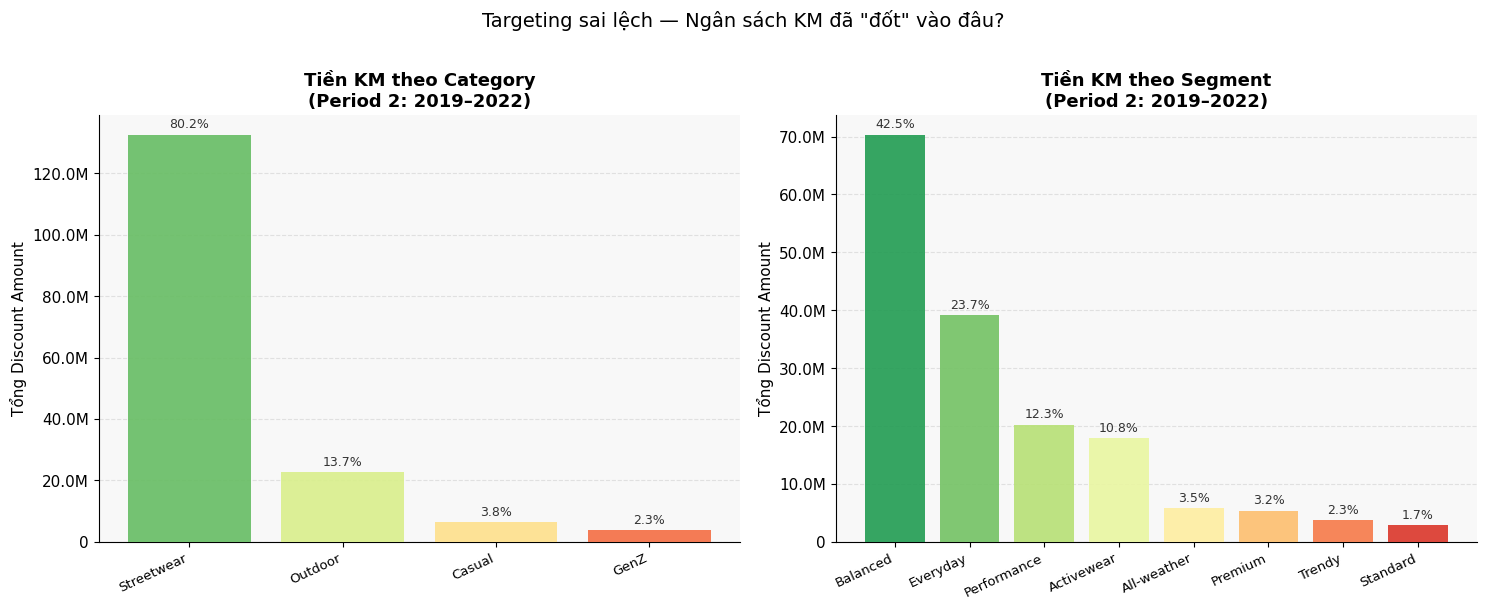

✅ Saved: output_2_3_targeting.png


In [14]:
def fmt_money(x, pos=None):
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    if abs(x) >= 1e3: return f'{x/1e3:.1f}K'
    return f'{x:,.0f}'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── By Category ───────────────────────────────────────────────────────────
ax1 = axes[0]
n_cat      = len(discount_by_cat)
colors_cat = sns.color_palette('RdYlGn_r', n_cat)

bars = ax1.bar(range(n_cat), discount_by_cat['total_discount'], color=colors_cat, alpha=0.9, zorder=3)
ax1.set_xticks(range(n_cat))
ax1.set_xticklabels(discount_by_cat['category'], rotation=25, ha='right', fontsize=9.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax1.set_ylabel('Tổng Discount Amount', fontsize=11)
ax1.set_title('Tiền KM theo Category\n(Period 2: 2019–2022)', fontsize=13)

for bar, pct in zip(bars, discount_by_cat['pct']):
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        h + discount_by_cat['total_discount'].max() * 0.01,
        f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color='#333'
    )

# ── By Segment ────────────────────────────────────────────────────────────
ax2 = axes[1]
n_seg      = len(discount_by_seg)
colors_seg = sns.color_palette('RdYlGn_r', n_seg)

bars2 = ax2.bar(range(n_seg), discount_by_seg['total_discount'], color=colors_seg, alpha=0.9, zorder=3)
ax2.set_xticks(range(n_seg))
ax2.set_xticklabels(discount_by_seg['segment'], rotation=25, ha='right', fontsize=9.5)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax2.set_ylabel('Tổng Discount Amount', fontsize=11)
ax2.set_title('Tiền KM theo Segment\n(Period 2: 2019–2022)', fontsize=13)

for bar, pct in zip(bars2, discount_by_seg['pct']):
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        h + discount_by_seg['total_discount'].max() * 0.01,
        f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color='#333'
    )

fig.suptitle('Targeting sai lệch — Ngân sách KM đã "đốt" vào đâu?', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print('✅ Saved: output_2_3_targeting.png')

## 2.4 Bonus: Heatmap % Discount Rate theo Category × Năm (P2) — Xem escalation

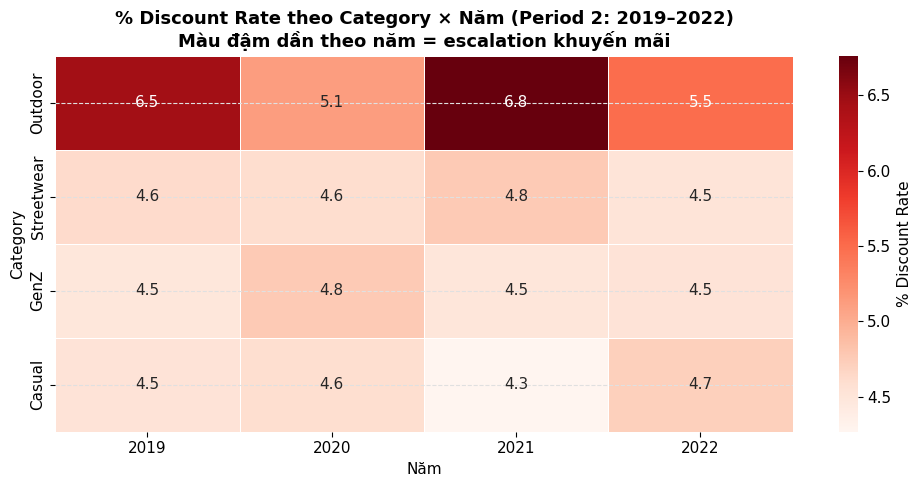

✅ Saved: output_2_4_heatmap.png


In [15]:
# ── Heatmap: discount rate theo category × year trong P2 ──────────────────
discount_cat_year = (
    items_p2
    .groupby(['year', 'category'])
    .agg(
        total_discount=('discount_amount', 'sum'),
        total_gross=('gross_item', 'sum')
    )
    .reset_index()
)
discount_cat_year['discount_rate'] = np.where(
    discount_cat_year['total_gross'] > 0,
    discount_cat_year['total_discount'] / discount_cat_year['total_gross'] * 100,
    0
)

heat_pivot = discount_cat_year.pivot(index='category', columns='year', values='discount_rate').fillna(0)
# Sort by mean discount rate (cao nhất trên đầu)
heat_pivot = heat_pivot.loc[heat_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heat_pivot,
    annot=True, fmt='.1f', cmap='Reds',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': '% Discount Rate'}
)
ax.set_title(
    '% Discount Rate theo Category × Năm (Period 2: 2019–2022)\n'
    'Màu đậm dần theo năm = escalation khuyến mãi', fontsize=13
)
ax.set_xlabel('Năm', fontsize=11)
ax.set_ylabel('Category', fontsize=11)

plt.tight_layout()
plt.show()
print('✅ Saved: output_2_4_heatmap.png')

## 2.5 Bonus: Promo Type Breakdown — Loại khuyến mãi nào được dùng nhiều nhất?

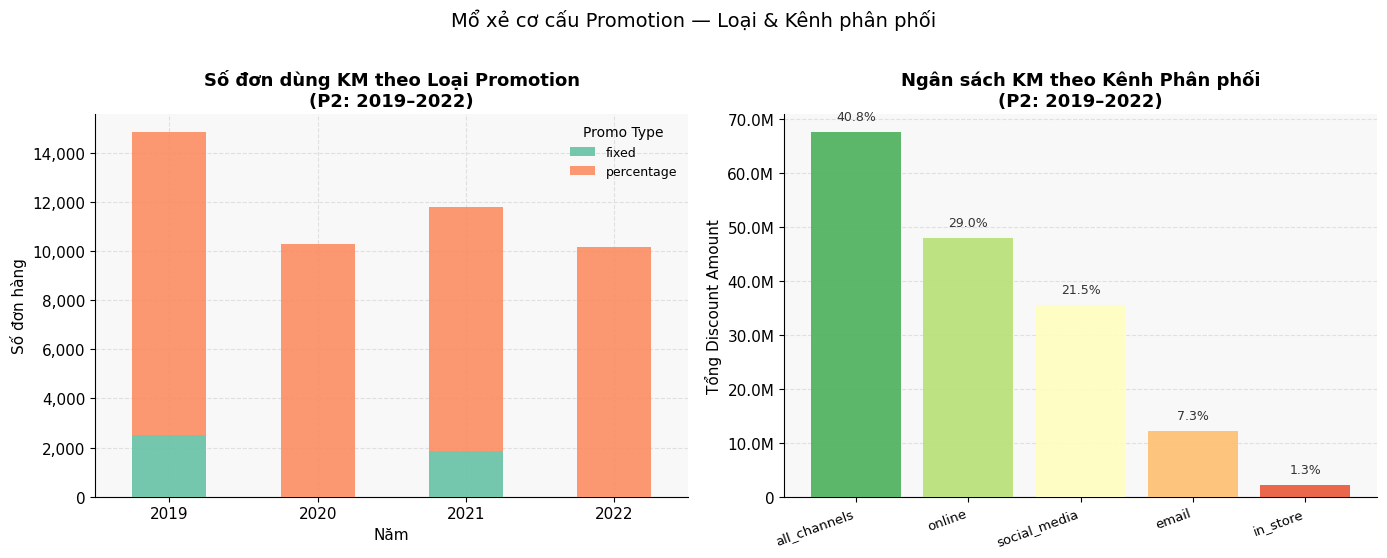

✅ Saved: output_2_5_promo_breakdown.png


In [16]:
# ── Join items_p2 với promotions để lấy promo_type ────────────────────────
# Schema: order_items.promo_id → promotions.promo_id → promo_type, discount_value
items_p2_promo = items_p2[items_p2['promo_id'].notna()].merge(
    promotions[['promo_id', 'promo_type', 'discount_value', 'applicable_category', 'promo_channel']],
    on='promo_id', how='left'
)

# Tổng discount theo promo_type × year
promo_type_year = (
    items_p2_promo
    .groupby(['year', 'promo_type'])
    .agg(
        total_discount=('discount_amount', 'sum'),
        n_orders=('order_id', 'nunique')
    )
    .reset_index()
)

# Pivot để vẽ stacked bar
pt_pivot = promo_type_year.pivot(index='year', columns='promo_type', values='n_orders').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Stacked bar: số đơn theo promo_type × year ---
ax1 = axes[0]
pt_colors = sns.color_palette('Set2', len(pt_pivot.columns))
pt_pivot.plot(kind='bar', stacked=True, ax=ax1, color=pt_colors, alpha=0.9, zorder=3)
ax1.set_title('Số đơn dùng KM theo Loại Promotion\n(P2: 2019–2022)', fontsize=13)
ax1.set_xlabel('Năm', fontsize=11)
ax1.set_ylabel('Số đơn hàng', fontsize=11)
ax1.set_xticklabels(pt_pivot.index, rotation=0)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.legend(title='Promo Type', fontsize=9, title_fontsize=10)

# --- Bar: tổng discount_amount theo promo_channel ---
ax2 = axes[1]
channel_disc = (
    items_p2_promo
    .groupby('promo_channel')['discount_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
ch_colors = sns.color_palette('RdYlGn_r', len(channel_disc))
bars = ax2.bar(range(len(channel_disc)), channel_disc['discount_amount'],
               color=ch_colors, alpha=0.9, zorder=3)
ax2.set_xticks(range(len(channel_disc)))
ax2.set_xticklabels(channel_disc['promo_channel'], rotation=20, ha='right', fontsize=9.5)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax2.set_ylabel('Tổng Discount Amount', fontsize=11)
ax2.set_title('Ngân sách KM theo Kênh Phân phối\n(P2: 2019–2022)', fontsize=13)

total_disc = channel_disc['discount_amount'].sum()
for bar, v in zip(bars, channel_disc['discount_amount']):
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        h + total_disc * 0.01,
        f'{v/total_disc*100:.1f}%', ha='center', va='bottom', fontsize=9, color='#333'
    )

fig.suptitle('Mổ xẻ cơ cấu Promotion — Loại & Kênh phân phối', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print('✅ Saved: output_2_5_promo_breakdown.png')

---
## 📌 Tóm tắt phát hiện

| # | Phân tích | Câu hỏi | Kỳ vọng phát hiện |
|---|-----------|---------|--------------------|
| 1.1 | Age Group | Age group nào co lại mạnh nhất ở P2? | Nhóm core (30-45?) giảm tỷ trọng |
| 1.2 | Region | Region nào bị mất khách nặng nhất? | Vài region sụt > 10pp |
| 1.3 | Category Volume | Category nào bốc hơi? | Top 1-2 category có drop > 40% |
| 2.1 | Promo Rate | Có leo thang lạm dụng promo không? | Rate tăng liên tục từ 2019 |
| 2.2 | Promo Fatigue | Discount cao hơn có kéo volume không? | Scatter P2 phẳng/âm = lờn thuốc |
| 2.3 | Targeting | Tiền KM chảy vào đâu? | Nhóm sản phẩm sai = lãng phí |
| 2.4 | Heatmap | Có category nào escalate discount? | Màu đậm dần theo năm |
| 2.5 | Promo Type & Channel | Loại KM nào được lạm dụng nhất? | Một loại chiếm quá lớn |

> **Next step:** Nếu giả thuyết được xác nhận → đề xuất giải pháp tập trung retention nhóm khách lõi + tái thiết kế chính sách Promotion theo segment/category thay vì mass discount.

In [18]:
import pandas as pd

inventory = pd.read_csv(INPUT_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
# Giả định bạn đã load các dataframes: orders, order_items, products, inventory

# =====================================================================
# BƯỚC 1: TÍNH TỔNG SỐ LƯỢNG BÁN THỰC TẾ (Từ hệ thống Transaction)
# =====================================================================
# Chỉ tính đơn hàng giao thành công
delivered_orders = orders[orders['order_status'] == 'delivered']

# Tính tổng quantity bán ra cho mỗi product_id
actual_sales = (
    order_items[order_items['order_id'].isin(delivered_orders['order_id'])]
    .groupby('product_id')['quantity']
    .sum()
    .reset_index(name='total_sold_qty')
)

# =====================================================================
# BƯỚC 2: TÍNH TỔNG SỐ NGÀY ĐỨT HÀNG (Từ hệ thống Inventory)
# =====================================================================
# Mỗi dòng trong bảng inventory là 1 snapshot theo ngày. 
# Ta đếm số lần stockout_flag == 1 (tương đương tổng số ngày đứt hàng)
stockout_stats = (
    inventory.groupby('product_id')
    .agg(
        total_stockout_days=('stockout_flag', 'sum'),
        avg_sell_through_rate=('sell_through_rate', 'mean') # Tham khảo thêm tốc độ bán
    )
    .reset_index()
)

# =====================================================================
# BƯỚC 3: GỘP BẢNG, GẮN TÊN SẢN PHẨM & TÍNH RANKING
# =====================================================================
# Gộp 2 bảng lại và lấy thêm thông tin từ bảng products
match_df = (
    products[['product_id', 'product_name', 'category', 'segment']]
    .merge(actual_sales, on='product_id', how='left')
    .merge(stockout_stats, on='product_id', how='left')
).fillna(0) # Đề phòng có hàng chưa bán được cái nào hoặc chưa từng đứt hàng

# Tạo Ranking (Xếp hạng) để dễ đối chiếu
# Hạng 1 là bán chạy nhất / Hạng 1 là đứt hàng nhiều ngày nhất
match_df['sales_rank'] = match_df['total_sold_qty'].rank(ascending=False, method='min')
match_df['stockout_rank'] = match_df['total_stockout_days'].rank(ascending=False, method='min')

# Tính độ lệch Hạng (Chênh lệch càng nhỏ chứng tỏ Bán càng chạy thì càng dễ hết hàng)
match_df['rank_diff'] = abs(match_df['sales_rank'] - match_df['stockout_rank'])


# =====================================================================
# BƯỚC 4: IN KẾT QUẢ ĐỂ CHECK BẰNG MẮT (Hoặc xuất CSV)
# =====================================================================

print("--- TOP 10 SẢN PHẨM BÁN CHẠY NHẤT (VÀ TÌNH TRẠNG KHO CỦA CHÚNG) ---")
top_sales = match_df.sort_values('sales_rank').head(10)
print(top_sales[['product_id', 'product_name', 'total_sold_qty', 'total_stockout_days', 'stockout_rank']].to_string(index=False))

print("\n--- TOP 10 SẢN PHẨM ĐỨT HÀNG NHIỀU NHẤT (VÀ DOANH SỐ CỦA CHÚNG) ---")
top_stockout = match_df.sort_values('stockout_rank').head(10)
print(top_stockout[['product_id', 'product_name', 'total_stockout_days', 'total_sold_qty', 'sales_rank']].to_string(index=False))

# Xuất ra file để bạn tự soi chiếu kỹ hơn nếu cần
match_df.to_csv('product_sales_vs_stockout.csv', index=False)
print("\n✅ Đã lưu file 'product_sales_vs_stockout.csv' để kiểm tra chi tiết!")

--- TOP 10 SẢN PHẨM BÁN CHẠY NHẤT (VÀ TÌNH TRẠNG KHO CỦA CHÚNG) ---
 product_id      product_name  total_sold_qty  total_stockout_days  stockout_rank
        791 HanoiStreet RP-79       36,517.00                77.00          69.00
        792 HanoiStreet RP-80       35,988.00                67.00         120.00
        604  SaigonFlex UC-69       29,368.00                90.00           4.00
       2045     UrbanVN UE-05       28,866.00                78.00          63.00
        487  SaigonFlex UM-92       26,583.00                48.00         269.00
       2332  VietMotion UE-06       26,184.00                80.00          46.00
       1182   MekongFit UE-18       25,512.00                93.00           2.00
        438  SaigonFlex UM-43       25,183.00                58.00         174.00
        927 HanoiStreet UE-36       24,911.00                79.00          53.00
        826 HanoiStreet UM-10       23,010.00                73.00          86.00

--- TOP 10 SẢN PHẨM ĐỨT HÀNG 

Hãy nhìn vào cột category và total_sold_qty qua 2 giai đoạn:

Thời kỳ Hoàng kim (2012 - 2015): Top 3 sản phẩm bán chạy nhất 100% là đồ Outdoor (thuộc dòng HanoiStreet). Đỉnh điểm là năm 2014, siêu phẩm HanoiStreet RP-79 bán được tới gần 10,000 đơn vị/năm.

Thời kỳ Suy thoái (2019 - 2022): Đồ Outdoor hoàn toàn biến mất khỏi bảng xếp hạng. Top 3 bị thống trị tuyệt đối bởi Streetwear (dòng SaigonFlex). Nhưng bi đát ở chỗ, "vua doanh số" của năm 2020 (UM-43) chỉ bán được vỏn vẹn 4,048 đơn vị — tức là chưa bằng một nửa so với đỉnh cao của Outdoor trước kia.

👉 Kết luận: Doanh nghiệp không "tự nhiên" bị sụt giảm Volume. Họ đã đánh mất hoàn toàn mảng kinh doanh cốt lõi (Outdoor) — mảng từng mang lại volume khổng lồ và (như phân tích Retention trước đó) có tỷ lệ khách hàng trung thành cao nhất. Họ chuyển sang bán Streetwear nhưng sức mua của tệp này quá yếu.

In [19]:
import pandas as pd
import numpy as np

# Giả định bạn đã load: orders, order_items, products, inventory

print("🔄 Đang xử lý đối chiếu Kho bãi & Doanh số theo từng năm...")

# =====================================================================
# BƯỚC 1: TÍNH SALES THEO NĂM
# =====================================================================
orders_v = orders[orders['order_status'] == 'delivered'].copy()
# Ép kiểu an toàn và lấy ra Năm
orders_v['order_date'] = pd.to_datetime(orders_v['order_date'])
orders_v['year'] = orders_v['order_date'].dt.year

sales_yearly = (
    order_items.merge(orders_v[['order_id', 'year']], on='order_id')
    .groupby(['year', 'product_id'])['quantity'].sum()
    .reset_index(name='total_sold_qty')
)

# =====================================================================
# BƯỚC 2: TÍNH STOCKOUT THEO NĂM
# =====================================================================
# Bảng inventory đã có sẵn cột 'year' theo schema, ta dùng luôn!
stockout_yearly = (
    inventory.groupby(['year', 'product_id'])['stockout_flag'].sum()
    .reset_index(name='total_stockout_days')
)

# =====================================================================
# BƯỚC 3: GỘP BẢNG VÀ TÍNH RANKING (TÁCH RIÊNG TỪNG NĂM)
# =====================================================================
# Dùng outer join để giữ cả những sản phẩm bán được nhưng không đứt hàng, và ngược lại
match_yearly = pd.merge(sales_yearly, stockout_yearly, on=['year', 'product_id'], how='outer').fillna(0)
match_yearly = match_yearly.merge(products[['product_id', 'product_name', 'category']], on='product_id', how='left')

# Tính Rank cho từng năm (Dùng groupby('year'))
match_yearly['sales_rank'] = match_yearly.groupby('year')['total_sold_qty'].rank(ascending=False, method='min')
match_yearly['stockout_rank'] = match_yearly.groupby('year')['total_stockout_days'].rank(ascending=False, method='min')

match_yearly['rank_diff'] = abs(match_yearly['sales_rank'] - match_yearly['stockout_rank'])

# =====================================================================
# BƯỚC 4: IN KẾT QUẢ (TOP 3 BÁN CHẠY CỦA TỪNG NĂM)
# =====================================================================
print("\n--- TOP 3 SẢN PHẨM BÁN CHẠY NHẤT MỖI NĂM & TÌNH TRẠNG KHO CỦA CHÚNG ---")

# Lọc Top 3 bán chạy mỗi năm
top_per_year = match_yearly[match_yearly['sales_rank'] <= 3].sort_values(['year', 'sales_rank'])

# Format lại bảng in cho gọn gàng dễ đọc
format_cols = ['year', 'sales_rank', 'product_name', 'category', 'total_sold_qty', 'stockout_rank', 'total_stockout_days']
print(top_per_year[format_cols].to_string(index=False))

# Xuất Full data để bạn quăng vào Excel làm Pivot Table hoặc vẽ chart
match_yearly.to_csv('yearly_sales_vs_stockout.csv', index=False)
print("\n✅ Đã lưu toàn bộ lịch sử 10 năm vào 'yearly_sales_vs_stockout.csv'")

🔄 Đang xử lý đối chiếu Kho bãi & Doanh số theo từng năm...

--- TOP 3 SẢN PHẨM BÁN CHẠY NHẤT MỖI NĂM & TÌNH TRẠNG KHO CỦA CHÚNG ---
 year  sales_rank      product_name   category  total_sold_qty  stockout_rank  total_stockout_days
 2012        1.00 HanoiStreet RP-74    Outdoor        5,010.00          38.00                 5.00
 2012        2.00 HanoiStreet RP-73    Outdoor        4,893.00          38.00                 5.00
 2012        3.00 HanoiStreet RP-45    Outdoor        2,809.00         248.00                 3.00
 2013        1.00 HanoiStreet RP-74    Outdoor        7,228.00         148.00                 8.00
 2013        2.00 HanoiStreet RP-73    Outdoor        7,096.00         315.00                 6.00
 2013        3.00 HanoiStreet UC-27 Streetwear        3,722.00         231.00                 7.00
 2014        1.00 HanoiStreet RP-79    Outdoor        9,923.00         132.00                 8.00
 2014        2.00 HanoiStreet RP-80    Outdoor        9,541.00         132.0

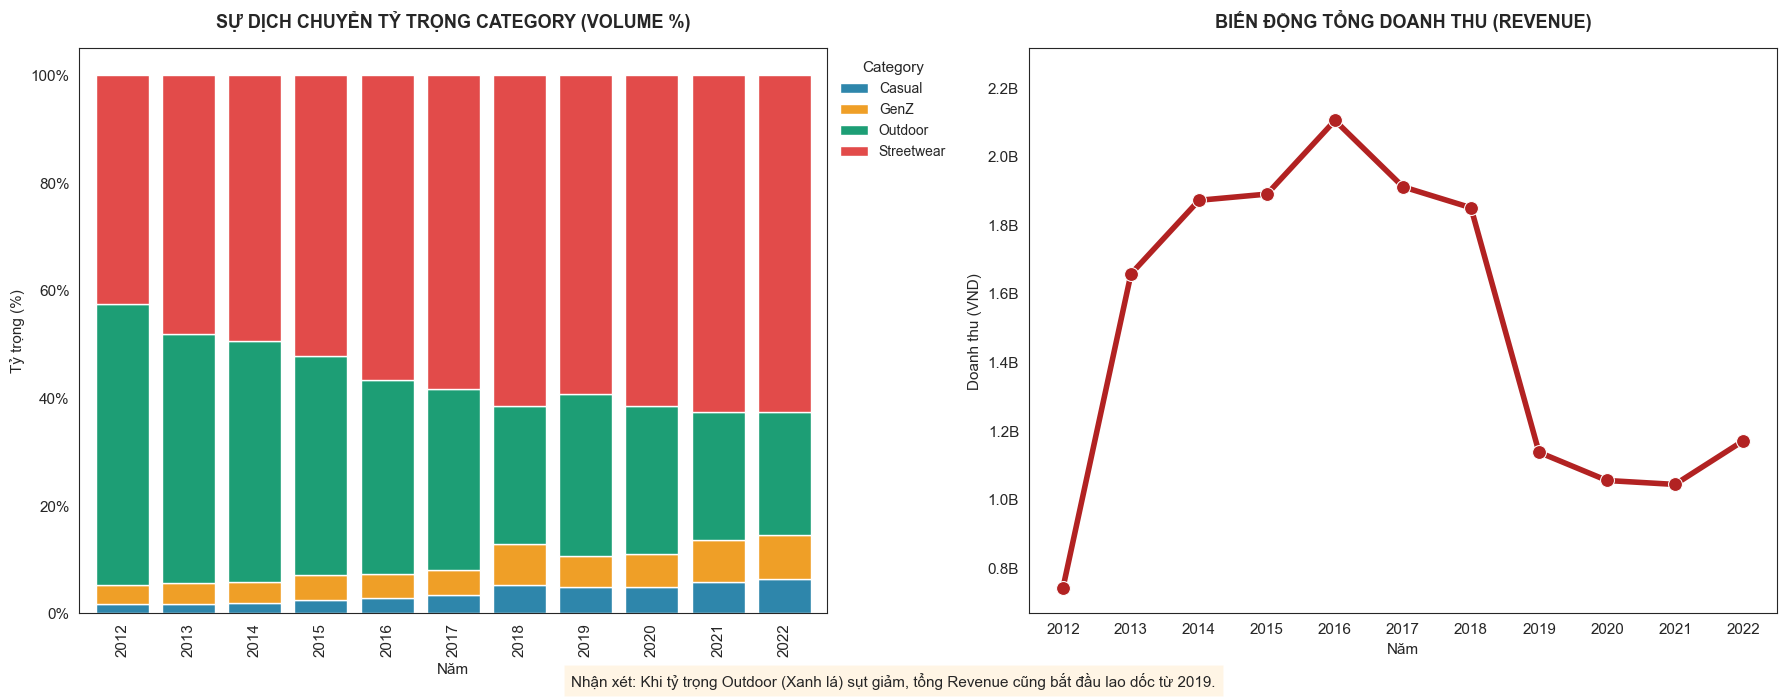

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

sales = pd.read_csv(INPUT_DIR / 'sales.csv')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# --- 1. CHUẨN BỊ DỮ LIỆU ---
# Stacked Bar: Tỷ trọng Category theo Year
cat_mix = match_yearly.groupby(['year', 'category'])['total_sold_qty'].sum().unstack().fillna(0)
cat_mix_pct = cat_mix.divide(cat_mix.sum(axis=1), axis=0) * 100

# Revenue: Doanh thu theo Year (từ bảng sales)
sales['Date'] = pd.to_datetime(sales['Date'])
sales['Year'] = sales['Date'].dt.year
yearly_rev = sales.groupby('Year')['Revenue'].sum().reset_index()

# --- 2. VẼ BIỂU ĐỒ ---
# Thiết lập style trắng, không grid
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# BẢNG MÀU ĐẶC TRƯNG
colors = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
# Lấy list màu theo đúng thứ tự các cột trong cat_mix_pct
color_list = [colors.get(c, '#888780') for c in cat_mix_pct.columns]

# BIỂU ĐỒ TRÁI: STACKED BAR (CƠ CẤU %)
cat_mix_pct.plot(kind='bar', stacked=True, ax=ax1, color=color_list, width=0.8, edgecolor='white')
ax1.set_title('SỰ DỊCH CHUYỂN TỶ TRỌNG CATEGORY (VOLUME %)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Tỷ trọng (%)')
ax1.set_xlabel('Năm')
ax1.legend(title='Category', bbox_to_anchor=(1.0, 1.0))
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.grid(False) # Bỏ gridline

# BIỂU ĐỒ PHẢI: REVENUE TREND (DOANH THU THUẦN)
sns.lineplot(data=yearly_rev, x='Year', y='Revenue', ax=ax2, color='#B22222', linewidth=4, marker='o', markersize=10)
ax2.set_title('BIẾN ĐỘNG TỔNG DOANH THU (REVENUE)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Doanh thu (VND)')
ax2.set_xlabel('Năm')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Đồng bộ trục X giữa 2 biểu đồ (chỉ hiện năm nguyên)
ax2.set_xticks(yearly_rev['Year'].unique())
ax2.grid(False) # Bỏ gridline

# Zoom trục Y của Revenue để thấy rõ độ dốc sụt giảm
ax2.set_ylim(yearly_rev['Revenue'].min() * 0.9, yearly_rev['Revenue'].max() * 1.1)

# Thêm ghi chú về sự tương quan
plt.figtext(0.5, 0.01, "Nhận xét: Khi tỷ trọng Outdoor (Xanh lá) sụt giảm, tổng Revenue cũng bắt đầu lao dốc từ 2019.", 
            ha="center", fontsize=11, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

plt.tight_layout()
plt.show()

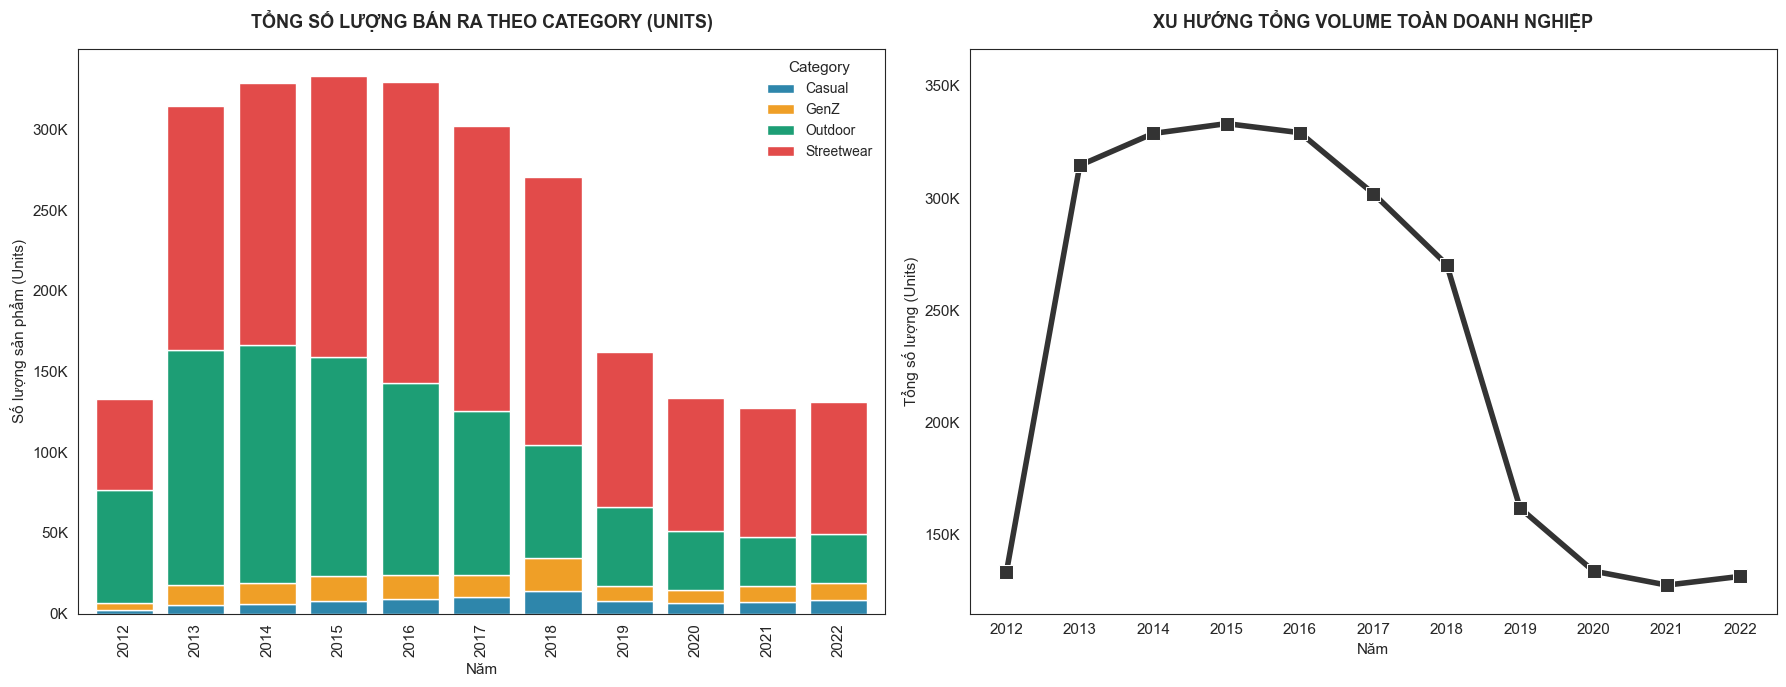

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# --- 1. CHUẨN BỊ DỮ LIỆU ---
# Lấy tổng Volume (Quantity) thực tế theo từng Category mỗi năm
volume_mix = match_yearly.groupby(['year', 'category'])['total_sold_qty'].sum().unstack().fillna(0)
# Tổng Volume toàn doanh nghiệp theo năm
total_volume_yearly = volume_mix.sum(axis=1).reset_index(name='total_qty')

# Tính toán đơn giá trung bình (Average Unit Price - AUP) để xem giá trị mỗi sản phẩm có giảm không
aup_analysis = match_yearly.groupby(['year', 'category']).agg({
    'total_sold_qty': 'sum'
}).reset_index()

# --- 2. VẼ BIỂU ĐỒ ---
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Cấu hình màu sắc nhất quán
colors = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
color_list = [colors.get(c, '#888780') for c in volume_mix.columns]

# BIỂU ĐỒ TRÁI: STACKED BAR (CƠ CẤU VOLUME THEO SỐ LƯỢNG TUYỆT ĐỐI)
# Thay vì nhìn %, hãy nhìn xem thực tế chúng ta bán được bao nhiêu cái
volume_mix.plot(kind='bar', stacked=True, ax=ax1, color=color_list, width=0.8, edgecolor='white')
ax1.set_title('TỔNG SỐ LƯỢNG BÁN RA THEO CATEGORY (UNITS)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Số lượng sản phẩm (Units)')
ax1.set_xlabel('Năm')
ax1.legend(title='Category', bbox_to_anchor=(1.0, 1.0))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.grid(False)

# BIỂU ĐỒ PHẢI: XU HƯỚNG TỔNG VOLUME
sns.lineplot(data=total_volume_yearly, x='year', y='total_qty', ax=ax2, color='#333333', linewidth=4, marker='s', markersize=10)
ax2.set_title('XU HƯỚNG TỔNG VOLUME TOÀN DOANH NGHIỆP', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Tổng số lượng (Units)')
ax2.set_xlabel('Năm')
ax2.set_xticks(total_volume_yearly['year'].unique())
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.grid(False)

# Zoom trục Y để thấy rõ độ dốc
ax2.set_ylim(total_volume_yearly['total_qty'].min() * 0.9, total_volume_yearly['total_qty'].max() * 1.1)

plt.tight_layout()
plt.show()

## 1.4 Vì sao Volume nhảy mạnh từ 2012 → 2013? Có phải do Promotion?

Phân tích nhanh dưới đây tách riêng:
- Volume đến từ đơn có promo vs không promo
- Mức độ phủ promo (promo penetration)
- Cường độ giảm giá (% discount trên gross)

Nếu phần tăng trưởng chủ yếu đến từ `promo volume` và penetration tăng rõ rệt, ta có bằng chứng rằng promotion là đòn bẩy chính của cú nhảy 2013.

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_9828\606989999.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')


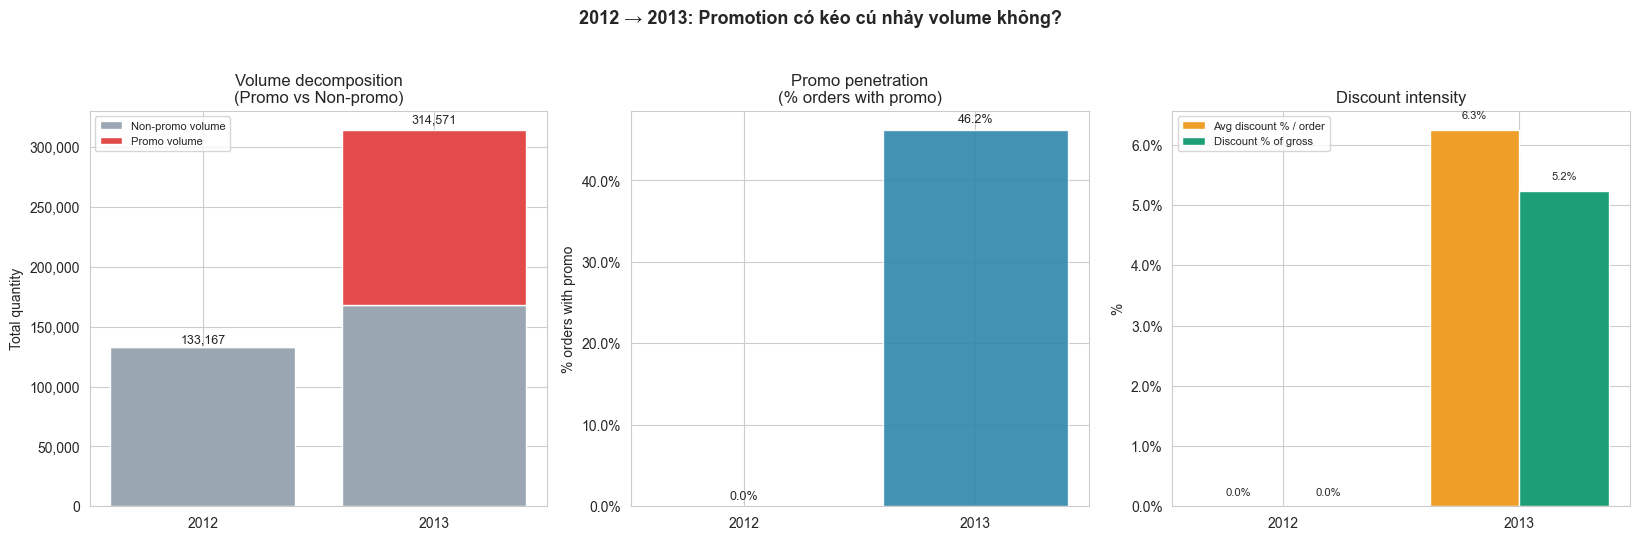

=== 2012 vs 2013 promo diagnostics ===
 year  total_orders  promo_orders  promo_penetration_pct  total_qty  promo_qty  nonpromo_qty  avg_discount_pct_order  discount_pct_of_gross
 2012         25663             0                   0.00     133167          0        133167                    0.00                   0.00
 2013         61588         28473                  46.23     314571     146364        168207                    6.25                   5.24

--- Contribution vào tăng trưởng volume 2013 ---
Delta total volume     : 181,404
Delta promo volume     : 146,364
Delta non-promo volume : 35,040
Promo contribution %   : 80.7%

Kết luận nhanh: Phần lớn cú nhảy volume 2013 đến từ promo-driven demand.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Dự phòng nếu notebook chưa có INPUT_DIR
try:
    INPUT_DIR
except NameError:
    from pathlib import Path
    INPUT_DIR = Path('input')

orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')

orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year'] = orders_d['order_date'].dt.year
orders_d = orders_d[orders_d['year'].isin([2012, 2013])]

items = order_items.merge(
    orders_d[['order_id', 'year', 'order_date']],
    on='order_id',
    how='inner'
)
items['gross_item'] = items['unit_price'] * items['quantity']
items['has_promo'] = (
    (items['discount_amount'].fillna(0) > 0) |
    (items['promo_id'].notna())
).astype(int)

# Gom về cấp order để tránh double-count
a_order = (
    items
    .groupby(['order_id', 'year'])
    .agg(
        order_qty=('quantity', 'sum'),
        order_gross=('gross_item', 'sum'),
        order_discount=('discount_amount', 'sum'),
        promo_order=('has_promo', 'max')
    )
    .reset_index()
)
a_order['order_discount'] = a_order['order_discount'].fillna(0)
a_order['discount_pct_order'] = np.where(
    a_order['order_gross'] > 0,
    a_order['order_discount'] / a_order['order_gross'] * 100,
    0
)

summary = (
    a_order
    .groupby('year')
    .agg(
        total_orders=('order_id', 'nunique'),
        promo_orders=('promo_order', 'sum'),
        total_qty=('order_qty', 'sum'),
        promo_qty=('order_qty', lambda x: x[a_order.loc[x.index, 'promo_order'] == 1].sum()),
        total_gross=('order_gross', 'sum'),
        total_discount=('order_discount', 'sum'),
        avg_discount_pct_order=('discount_pct_order', 'mean')
    )
    .reset_index()
)
summary['nonpromo_qty'] = summary['total_qty'] - summary['promo_qty']
summary['promo_penetration_pct'] = np.where(
    summary['total_orders'] > 0,
    summary['promo_orders'] / summary['total_orders'] * 100,
    0
)
summary['discount_pct_of_gross'] = np.where(
    summary['total_gross'] > 0,
    summary['total_discount'] / summary['total_gross'] * 100,
    0
)

# Contribution của promo vào phần tăng volume 2012 -> 2013
y12 = summary[summary['year'] == 2012].iloc[0]
y13 = summary[summary['year'] == 2013].iloc[0]

delta_total_qty = y13['total_qty'] - y12['total_qty']
delta_promo_qty = y13['promo_qty'] - y12['promo_qty']
delta_nonpromo_qty = y13['nonpromo_qty'] - y12['nonpromo_qty']

promo_contrib_pct = np.nan
if delta_total_qty != 0:
    promo_contrib_pct = delta_promo_qty / delta_total_qty * 100

# --- Plot ---
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
years = summary['year'].astype(str).tolist()

# (1) Stacked volume: promo vs non-promo
ax1 = axes[0]
ax1.bar(years, summary['nonpromo_qty'], color='#9AA6B2', label='Non-promo volume')
ax1.bar(years, summary['promo_qty'], bottom=summary['nonpromo_qty'], color='#E24B4A', label='Promo volume')
ax1.set_title('Volume decomposition\n(Promo vs Non-promo)')
ax1.set_ylabel('Total quantity')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.legend(fontsize=8)

for i, row in summary.reset_index().iterrows():
    ax1.text(i, row['total_qty'] * 1.01, f"{row['total_qty']:,.0f}", ha='center', va='bottom', fontsize=9)

# (2) Promo penetration theo order
ax2 = axes[1]
ax2.bar(years, summary['promo_penetration_pct'], color='#2E86AB', alpha=0.9)
ax2.set_title('Promo penetration\n(% orders with promo)')
ax2.set_ylabel('% orders with promo')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(summary['promo_penetration_pct']):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# (3) Discount intensity
ax3 = axes[2]
width = 0.38
x = np.arange(len(summary))
ax3.bar(x - width/2, summary['avg_discount_pct_order'], width, color='#EF9F27', label='Avg discount % / order')
ax3.bar(x + width/2, summary['discount_pct_of_gross'], width, color='#1D9E75', label='Discount % of gross')
ax3.set_xticks(x)
ax3.set_xticklabels(years)
ax3.set_title('Discount intensity')
ax3.set_ylabel('%')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter())
ax3.legend(fontsize=8)

for i, row in summary.reset_index().iterrows():
    ax3.text(i - width/2, row['avg_discount_pct_order'] + 0.15, f"{row['avg_discount_pct_order']:.1f}%", ha='center', va='bottom', fontsize=8)
    ax3.text(i + width/2, row['discount_pct_of_gross'] + 0.15, f"{row['discount_pct_of_gross']:.1f}%", ha='center', va='bottom', fontsize=8)

fig.suptitle('2012 → 2013: Promotion có kéo cú nhảy volume không?', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# --- In quick diagnostics ---
print('=== 2012 vs 2013 promo diagnostics ===')
print(summary[['year', 'total_orders', 'promo_orders', 'promo_penetration_pct',
               'total_qty', 'promo_qty', 'nonpromo_qty',
               'avg_discount_pct_order', 'discount_pct_of_gross']].round(2).to_string(index=False))

print('\n--- Contribution vào tăng trưởng volume 2013 ---')
print(f"Delta total volume     : {delta_total_qty:,.0f}")
print(f"Delta promo volume     : {delta_promo_qty:,.0f}")
print(f"Delta non-promo volume : {delta_nonpromo_qty:,.0f}")
if np.isnan(promo_contrib_pct):
    print('Promo contribution %   : N/A (không có tăng trưởng để chia)')
else:
    print(f"Promo contribution %   : {promo_contrib_pct:.1f}%")

if not np.isnan(promo_contrib_pct):
    if promo_contrib_pct >= 70:
        print('\nKết luận nhanh: Phần lớn cú nhảy volume 2013 đến từ promo-driven demand.')
    elif promo_contrib_pct >= 40:
        print('\nKết luận nhanh: Promotion đóng vai trò đáng kể, nhưng không phải yếu tố duy nhất.')
    else:
        print('\nKết luận nhanh: Promotion chỉ đóng góp một phần nhỏ; cần xem thêm non-promo drivers.')

In [2]:
# Kiểm chứng thêm: promo trong data bắt đầu từ năm nào?
promotions = pd.read_csv(INPUT_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
print('Promotion table date range:')
print(promotions[['start_date', 'end_date']].agg(['min', 'max']))

# Số order có promo_id theo năm (delivered)
check_items = order_items.merge(orders[['order_id', 'order_date', 'order_status']], on='order_id', how='left')
check_items = check_items[check_items['order_status'] == 'delivered'].copy()
check_items['year'] = pd.to_datetime(check_items['order_date']).dt.year

order_promo_year = (
    check_items.groupby(['year', 'order_id'])['promo_id']
    .apply(lambda s: int(s.notna().any()))
    .reset_index(name='has_promo_id')
    .groupby('year')['has_promo_id']
    .agg(total_orders='count', orders_with_promo_id='sum')
    .reset_index()
)
order_promo_year['promo_id_penetration_pct'] = np.where(
    order_promo_year['total_orders'] > 0,
    order_promo_year['orders_with_promo_id'] / order_promo_year['total_orders'] * 100,
    0
)

print('\nOrders with promo_id by year (first years):')
print(order_promo_year.sort_values('year').head(5).to_string(index=False))

Promotion table date range:
    start_date   end_date
min 2013-01-31 2013-03-01
max 2022-11-18 2022-12-31

Orders with promo_id by year (first years):
 year  total_orders  orders_with_promo_id  promo_id_penetration_pct
 2012         25663                     0                  0.000000
 2013         61588                 28473                 46.231409
 2014         64688                 23720                 36.668316
 2015         66163                 30514                 46.119432
 2016         66067                 22828                 34.552802


## 1.5 Vì sao Volume giảm mạnh từ 2018 trở đi? Promotion có phải nguyên nhân?

Phân tích này tách thành 3 lớp:
- **Lớp 1:** Volume toàn công ty được tách thành `promo volume` vs `non-promo volume`
- **Lớp 2:** Cường độ promo theo năm (`promo penetration`, `%discount/gross`)
- **Lớp 3:** Cấu trúc chiến dịch thay đổi qua năm (số campaign, promo type, channel, discount value)

Mục tiêu là xác định: giai đoạn sau 2018 giảm vì **cắt promo**, hay giảm dù promo vẫn cao (dấu hiệu suy yếu nhu cầu nền).

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_9828\3065459090.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')


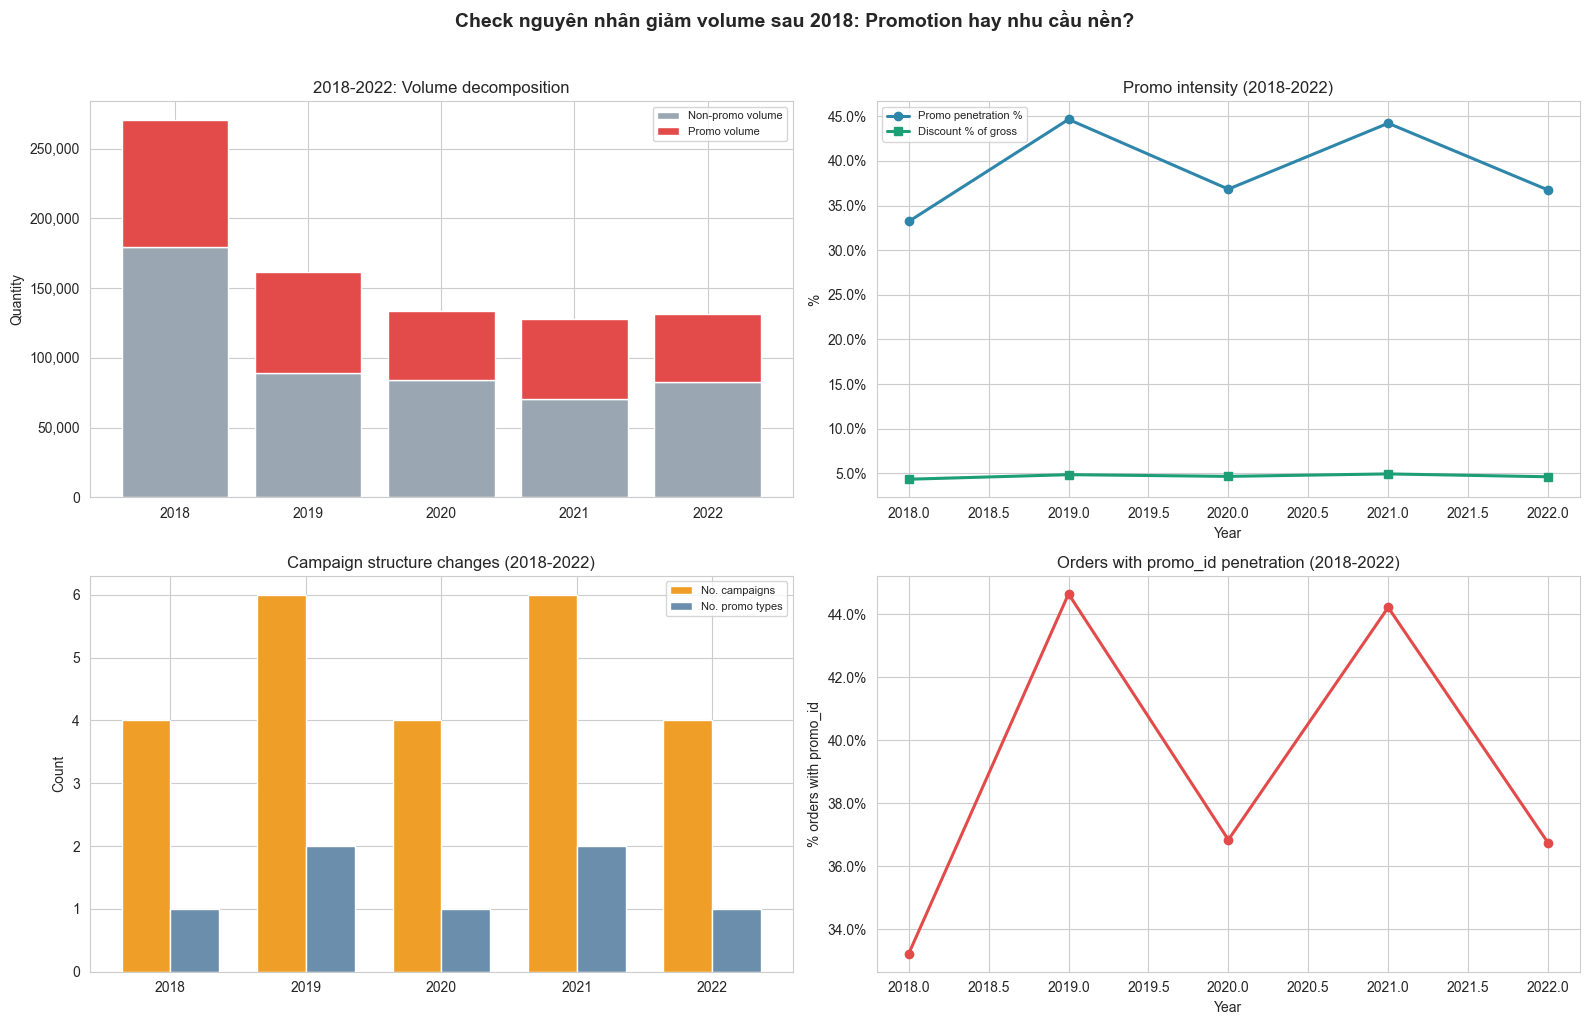

=== Volume & promo diagnostics: 2018-2022 ===
 year  total_qty  promo_qty  nonpromo_qty  promo_penetration_pct  discount_pct_of_gross
 2018     270404      90815        179589                  33.22                   4.35
 2019     161837      72595         89242                  44.65                   4.86
 2020     133785      49756         84029                  36.84                   4.67
 2021     127542      56855         70687                  44.22                   4.94
 2022     131433      48768         82665                  36.74                   4.62

=== Delta decomposition (YoY) ===
 year  delta_total_qty  delta_promo_qty  delta_nonpromo_qty  promo_contrib_to_delta_pct
 2018              NaN              NaN                 NaN                         NaN
 2019        -108567.0         -18220.0            -90347.0                       16.78
 2020         -28052.0         -22839.0             -5213.0                       81.42
 2021          -6243.0           7099.0

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Dùng lại INPUT_DIR nếu đã có
try:
    INPUT_DIR
except NameError:
    from pathlib import Path
    INPUT_DIR = Path('input')

orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
promotions = pd.read_csv(INPUT_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])

orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year'] = orders_d['order_date'].dt.year

items = order_items.merge(
    orders_d[['order_id', 'year', 'order_date']],
    on='order_id',
    how='inner'
)
items['gross_item'] = items['unit_price'] * items['quantity']
items['discount_amount'] = items['discount_amount'].fillna(0)
items['has_promo'] = ((items['discount_amount'] > 0) | (items['promo_id'].notna())).astype(int)

# Cấp order-year để tách promo/non-promo volume
order_year = (
    items
    .groupby(['order_id', 'year'])
    .agg(
        order_qty=('quantity', 'sum'),
        order_gross=('gross_item', 'sum'),
        order_discount=('discount_amount', 'sum'),
        promo_order=('has_promo', 'max')
    )
    .reset_index()
)

yr = (
    order_year
    .groupby('year')
    .agg(
        total_orders=('order_id', 'nunique'),
        promo_orders=('promo_order', 'sum'),
        total_qty=('order_qty', 'sum'),
        promo_qty=('order_qty', lambda x: x[order_year.loc[x.index, 'promo_order'] == 1].sum()),
        total_gross=('order_gross', 'sum'),
        total_discount=('order_discount', 'sum')
    )
    .reset_index()
    .sort_values('year')
)

yr['nonpromo_qty'] = yr['total_qty'] - yr['promo_qty']
yr['promo_penetration_pct'] = np.where(yr['total_orders'] > 0, yr['promo_orders'] / yr['total_orders'] * 100, 0)
yr['discount_pct_of_gross'] = np.where(yr['total_gross'] > 0, yr['total_discount'] / yr['total_gross'] * 100, 0)

# Tập trung đoạn suy giảm
focus = yr[yr['year'].between(2018, 2022)].copy()

# Đóng góp của promo vào biến động volume từng năm (so với năm trước)
focus['delta_total_qty'] = focus['total_qty'].diff()
focus['delta_promo_qty'] = focus['promo_qty'].diff()
focus['delta_nonpromo_qty'] = focus['nonpromo_qty'].diff()
focus['promo_contrib_to_delta_pct'] = np.where(
    focus['delta_total_qty'] != 0,
    focus['delta_promo_qty'] / focus['delta_total_qty'] * 100,
    np.nan
)

# ---------- Campaign changes từ bảng promotions ----------
promo_year = promotions.copy()
promo_year['year'] = promo_year['start_date'].dt.year

camp_summary = (
    promo_year
    .groupby('year')
    .agg(
        n_campaigns=('promo_id', 'nunique'),
        avg_discount_value=('discount_value', 'mean'),
        median_discount_value=('discount_value', 'median')
    )
    .reset_index()
    .sort_values('year')
)

# Diversity của promo type/channel theo năm
camp_mix = (
    promo_year
    .groupby('year')
    .agg(
        n_promo_types=('promo_type', 'nunique'),
        n_channels=('promo_channel', 'nunique'),
        n_target_categories=('applicable_category', 'nunique')
    )
    .reset_index()
    .sort_values('year')
)

# Usage thực tế: đơn có promo_id theo năm
usage = (
    items.groupby(['year', 'order_id'])['promo_id']
    .apply(lambda s: int(s.notna().any()))
    .reset_index(name='has_promo_id')
    .groupby('year')['has_promo_id']
    .agg(total_orders='count', orders_with_promo_id='sum')
    .reset_index()
)
usage['promo_id_penetration_pct'] = np.where(
    usage['total_orders'] > 0,
    usage['orders_with_promo_id'] / usage['total_orders'] * 100,
    0
)

campaign_check = (
    usage
    .merge(camp_summary, on='year', how='left')
    .merge(camp_mix, on='year', how='left')
    .sort_values('year')
)

# ---------- Plot ----------
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) Volume decomposition
ax = axes[0, 0]
ax.bar(focus['year'].astype(str), focus['nonpromo_qty'], color='#9AA6B2', label='Non-promo volume')
ax.bar(focus['year'].astype(str), focus['promo_qty'], bottom=focus['nonpromo_qty'], color='#E24B4A', label='Promo volume')
ax.set_title('2018-2022: Volume decomposition')
ax.set_ylabel('Quantity')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=8)

# (2) Promo intensity
ax = axes[0, 1]
ax.plot(focus['year'], focus['promo_penetration_pct'], marker='o', color='#2E86AB', linewidth=2.2, label='Promo penetration %')
ax.plot(focus['year'], focus['discount_pct_of_gross'], marker='s', color='#1D9E75', linewidth=2.2, label='Discount % of gross')
ax.set_title('Promo intensity (2018-2022)')
ax.set_xlabel('Year')
ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=8)

# (3) Campaign count + diversity
ax = axes[1, 0]
cm = campaign_check[campaign_check['year'].between(2018, 2022)].copy()
width = 0.36
x = np.arange(len(cm))
ax.bar(x - width/2, cm['n_campaigns'], width, color='#EF9F27', label='No. campaigns')
ax.bar(x + width/2, cm['n_promo_types'], width, color='#6C8EAD', label='No. promo types')
ax.set_xticks(x)
ax.set_xticklabels(cm['year'].astype(int).astype(str))
ax.set_title('Campaign structure changes (2018-2022)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

# (4) Campaign usage in orders
ax = axes[1, 1]
ax.plot(cm['year'], cm['promo_id_penetration_pct'], marker='o', color='#E24B4A', linewidth=2.2)
ax.set_title('Orders with promo_id penetration (2018-2022)')
ax.set_xlabel('Year')
ax.set_ylabel('% orders with promo_id')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle('Check nguyên nhân giảm volume sau 2018: Promotion hay nhu cầu nền?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---------- Text diagnostics ----------
print('=== Volume & promo diagnostics: 2018-2022 ===')
print(focus[['year', 'total_qty', 'promo_qty', 'nonpromo_qty', 'promo_penetration_pct', 'discount_pct_of_gross']].round(2).to_string(index=False))

print('\n=== Delta decomposition (YoY) ===')
print(focus[['year', 'delta_total_qty', 'delta_promo_qty', 'delta_nonpromo_qty', 'promo_contrib_to_delta_pct']].round(2).to_string(index=False))

print('\n=== Campaign change check (2018-2022) ===')
print(cm[['year', 'n_campaigns', 'n_promo_types', 'n_channels', 'n_target_categories',
          'avg_discount_value', 'promo_id_penetration_pct']].round(2).to_string(index=False))

# Trả lời trực tiếp 2 câu hỏi
y2012 = yr[yr['year'] == 2012].iloc[0]
if y2012['promo_penetration_pct'] == 0:
    print('\n2012 thấp và gần như KHÔNG có promo trong data giao dịch (penetration = 0%).')
else:
    print('\n2012 thấp nhưng vẫn có một phần promo; cần kiểm tra thêm yếu tố ngoài promo.')

# Nhận định cho pha giảm sau 2018
avg_pen_18_22 = focus['promo_penetration_pct'].mean()
if avg_pen_18_22 > 25 and focus['total_qty'].iloc[-1] < focus['total_qty'].iloc[0]:
    print('Giai đoạn sau 2018: volume giảm dù promo vẫn hiện diện cao => promo KHÔNG phải nguyên nhân gốc duy nhất.')
else:
    print('Giai đoạn sau 2018: cần đọc thêm cấu trúc promo để kết luận nguyên nhân chính.')

In [28]:
# =====================================================================
# CELL 1: TÁI THIẾT LẬP DỮ LIỆU (Đảm bảo không lỗi NameError)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Cấu hình chung
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
INPUT_DIR = Path('input')

print("📂 Đang nạp dữ liệu và tính toán logic Cohort...")
orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')

# 1. Lọc đơn hàng thành công và tạo trục thời gian
orders_v = orders[orders['order_status'] == 'delivered'].copy()
orders_v['order_month'] = orders_v['order_date'].dt.to_period('M')

# 2. Xác định Đơn hàng đầu tiên và Category chủ đạo của đơn đó
first_orders = orders_v.sort_values('order_date').groupby('customer_id').first().reset_index()
first_items = order_items[order_items['order_id'].isin(first_orders['order_id'])]
first_items = first_items.merge(products[['product_id', 'category']], on='product_id', how='left')
first_items['net_rev'] = (first_items['unit_price'] * first_items['quantity']) - first_items['discount_amount']

# Chọn Category mang lại doanh thu cao nhất trong đơn đầu làm Main Category
main_cat = first_items.sort_values('net_rev', ascending=False).groupby('order_id').first().reset_index()
cat_mapping = main_cat.set_index('order_id')['category'].to_dict()

# 3. Gắn thông tin Month Index (Tháng quay lại)
orders_v = orders_v.merge(
    first_orders[['customer_id', 'order_id', 'order_month']].rename(
        columns={'order_id': 'first_order_id', 'order_month': 'first_month'}), 
    on='customer_id'
)
orders_v['first_category'] = orders_v['first_order_id'].map(cat_mapping)
orders_v['month_index'] = (orders_v['order_month'] - orders_v['first_month']).apply(lambda x: x.n)

print("✅ Đã chuẩn bị xong dữ liệu gốc!")

📂 Đang nạp dữ liệu và tính toán logic Cohort...
✅ Đã chuẩn bị xong dữ liệu gốc!


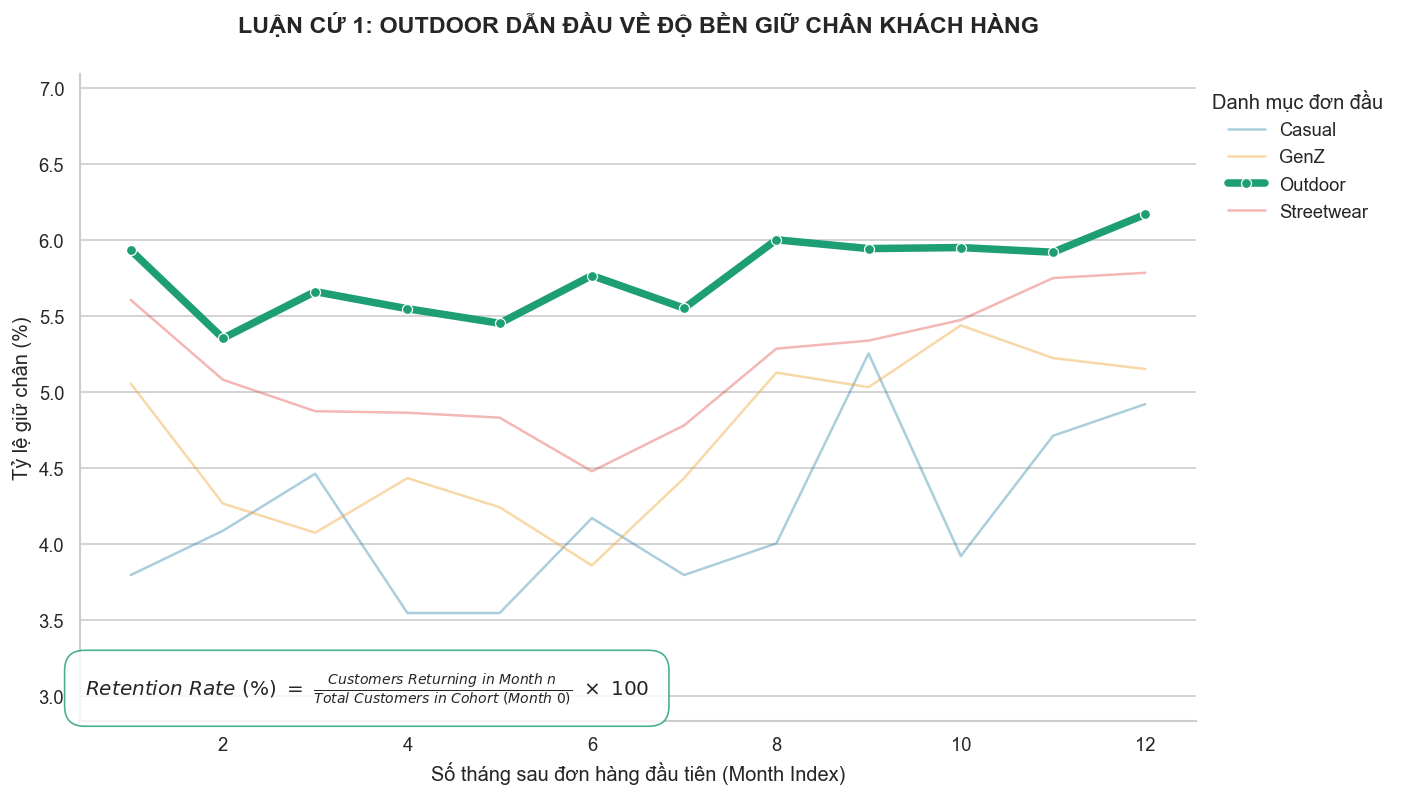

In [29]:
# =====================================================================
# CELL 2: LUẬN CỨ 1 - ĐỘ DỐC TRUNG THÀNH (KÈM CÔNG THỨC)
# =====================================================================
import matplotlib.patches as patches

# 1. Tính Retention Matrix
cohort_sizes = orders_v[orders_v['month_index'] == 0].groupby('first_category')['customer_id'].nunique()
ret_df = orders_v[orders_v['month_index'] > 0].groupby(['first_category', 'month_index'])['customer_id'].nunique().reset_index()
ret_df = ret_df.merge(cohort_sizes.rename('cohort_size'), on='first_category')
ret_df['retention_rate'] = (ret_df['customer_id'] / ret_df['cohort_size']) * 100
ret_pivot = ret_df[ret_df['month_index'] <= 12].pivot(index='month_index', columns='first_category', values='retention_rate')

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 7))
colors = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}

for cat in ret_pivot.columns:
    lw = 4.5 if cat == 'Outdoor' else 1.5
    alpha = 1.0 if cat == 'Outdoor' else 0.4
    sns.lineplot(data=ret_pivot, x=ret_pivot.index, y=cat, label=cat, 
                 color=colors.get(cat, '#888780'), linewidth=lw, alpha=alpha,
                 marker='o' if cat == 'Outdoor' else None)

# Chèn công thức tính Retention Rate
formula_text = r"$Retention\ Rate\ (\%)\ =\ \frac{Customers\ Returning\ in\ Month\ n}{Total\ Customers\ in\ Cohort\ (Month\ 0)}\ \times\ 100$"
plt.text(0.5, ret_pivot.values.min() * 0.85, formula_text, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#1D9E75', boxstyle='round,pad=1'))

plt.title('LUẬN CỨ 1: OUTDOOR DẪN ĐẦU VỀ ĐỘ BỀN GIỮ CHÂN KHÁCH HÀNG', fontsize=14, fontweight='bold', pad=25)
plt.xlabel('Số tháng sau đơn hàng đầu tiên (Month Index)')
plt.ylabel('Tỷ lệ giữ chân (%)')
plt.ylim(ret_pivot.values.min() * 0.8, ret_pivot['Outdoor'].max() * 1.15)
plt.legend(title='Danh mục đơn đầu', bbox_to_anchor=(1, 1))
sns.despine()
plt.show()

📊 Đang phân tích Chất lượng Lợi nhuận & LTV...


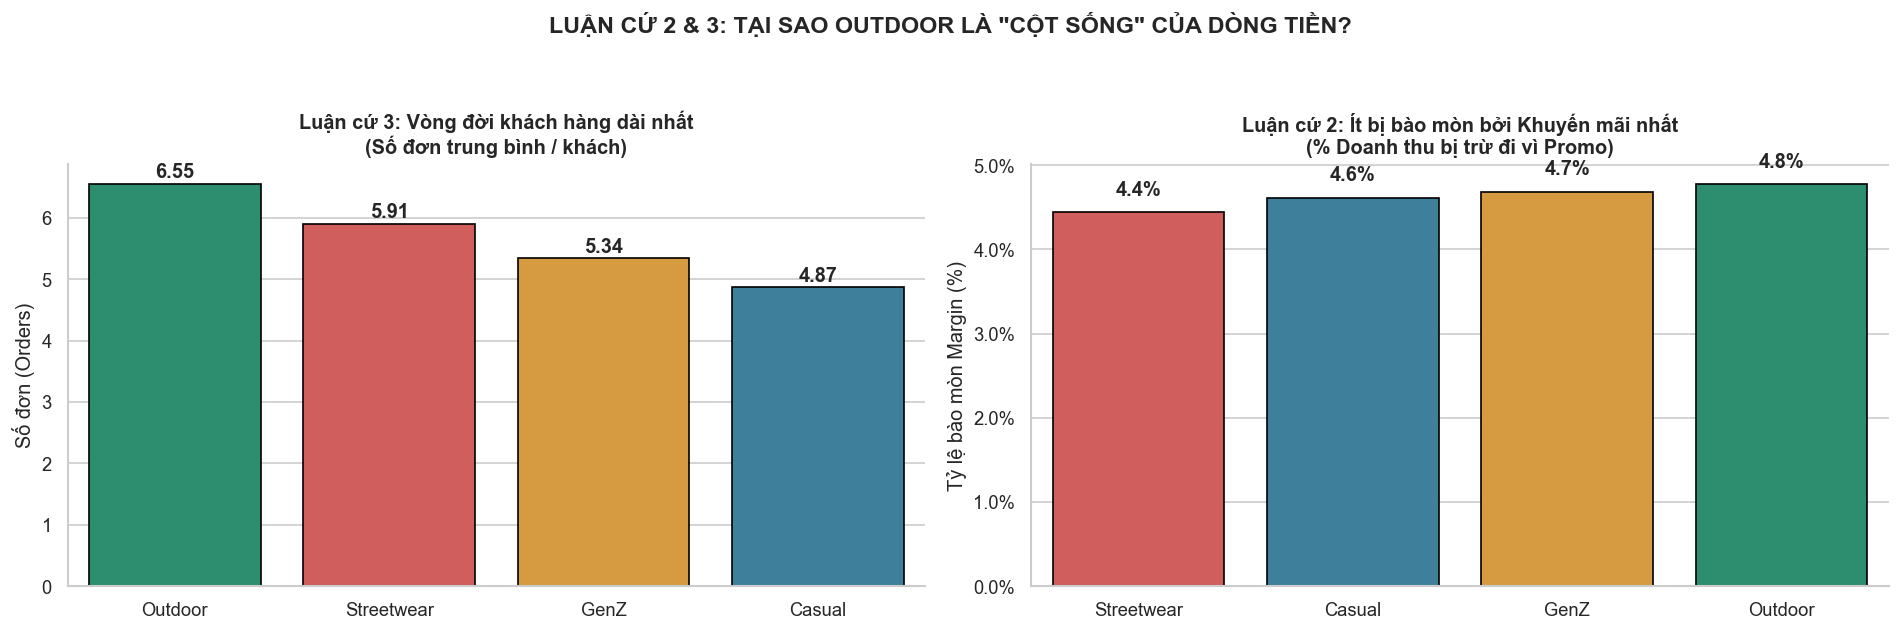

In [31]:
# =====================================================================
# CELL 3: LUẬN CỨ 2 & 3 - GIÁ TRỊ VÒNG ĐỜI (LTV) VÀ CHẤT LƯỢNG LỢI NHUẬN
# =====================================================================
import matplotlib.ticker as mticker

print("📊 Đang phân tích Chất lượng Lợi nhuận & LTV...")

# --- LUẬN CỨ 3: LTV PROXY (Khách mua trung bình mấy đơn?) ---
# Tính tổng số đơn hàng của mỗi khách hàng
user_orders = orders_v.groupby(['customer_id', 'first_category'])['order_id'].nunique().reset_index()
ltv_proxy = user_orders.groupby('first_category')['order_id'].mean().reset_index(name='avg_orders').sort_values('avg_orders', ascending=False)

# --- LUẬN CỨ 2: CHẤT LƯỢNG LỢI NHUẬN (Mua nguyên giá hay ăn Promo?) ---
# Gắn order_items vào category đơn đầu
items_v = order_items[order_items['order_id'].isin(orders_v['order_id'])].copy()
# Tính Revenue thực tế và Discount
items_v['gross_rev'] = items_v['unit_price'] * items_v['quantity']
items_v['discount'] = items_v['discount_amount'].fillna(0)

order_rev = items_v.groupby('order_id').agg({'gross_rev': 'sum', 'discount': 'sum'}).reset_index()
order_rev = order_rev.merge(orders_v[['order_id', 'first_category']], on='order_id')

# Tính % Doanh thu bị bốc hơi do Khuyến mãi (Discount Ratio) theo tệp KH
promo_quality = order_rev.groupby('first_category').agg({'gross_rev': 'sum', 'discount': 'sum'}).reset_index()
promo_quality['discount_ratio'] = (promo_quality['discount'] / promo_quality['gross_rev']) * 100
promo_quality = promo_quality.sort_values('discount_ratio')

# --- VẼ BIỂU ĐỒ KÉP ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('LUẬN CỨ 2 & 3: TẠI SAO OUTDOOR LÀ "CỘT SỐNG" CỦA DÒNG TIỀN?', fontsize=14, fontweight='bold', y=1.05)

palette = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}

# BÊN TRÁI: Số đơn trung bình (LTV)
sns.barplot(data=ltv_proxy, x='first_category', y='avg_orders', palette=palette, ax=ax1, edgecolor='black')
ax1.set_title('Luận cứ 3: Vòng đời khách hàng dài nhất\n(Số đơn trung bình / khách)', fontsize=12)
ax1.set_ylabel('Số đơn (Orders)')
ax1.set_xlabel('')
for i, v in enumerate(ltv_proxy['avg_orders']):
    ax1.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# BÊN PHẢI: Tỷ lệ "bốc hơi" doanh thu do Promo
sns.barplot(data=promo_quality, x='first_category', y='discount_ratio', palette=palette, ax=ax2, edgecolor='black')
ax2.set_title('Luận cứ 2: Ít bị bào mòn bởi Khuyến mãi nhất\n(% Doanh thu bị trừ đi vì Promo)', fontsize=12)
ax2.set_ylabel('Tỷ lệ bào mòn Margin (%)')
ax2.set_xlabel('')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(promo_quality['discount_ratio']):
    ax2.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

In [3]:
promotions = pd.read_csv(INPUT_DIR / 'promotions.csv')
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.00,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.00,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.00,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.00,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.00,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [4]:
shipments = pd.read_csv(INPUT_DIR / 'shipments.csv')
shipments.head()

,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79


In [7]:
returns = pd.read_csv(INPUT_DIR / 'returns.csv')
returns.head()

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.01"
1,RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.37"
2,RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.95"
3,RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.75"
4,RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.76"


In [8]:
reviews = pd.read_csv(INPUT_DIR / 'reviews.csv')
reviews.head()

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


In [10]:
# =====================================================================
# CELL 1: PHÂN TÍCH BIÊN LỢI NHUẬN GỘP (GROSS MARGIN) THEO CATEGORY
# =====================================================================
import pandas as pd
products = pd.read_csv(INPUT_DIR / 'products.csv')
# 1. Kết hợp order_items với thông tin COGS từ bảng products
# Lưu ý: Theo rules, dùng cogs từ products để tính tỷ lệ margin vì tỷ trọng vẫn đúng
items_margin = order_items.merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')

# 2. Tính Net Revenue (Doanh thu sau chiết khấu) và Total COGS
# Net_Revenue = (unit_price * quantity) - discount_amount
items_margin['net_revenue'] = (items_margin['unit_price'] * items_margin['quantity']) - items_margin['discount_amount']
items_margin['total_cogs'] = items_margin['cogs'] * items_margin['quantity']

# 3. Aggregate theo Category để tính Margin %
margin_stats = items_margin.groupby('category').agg(
    total_net_rev=('net_revenue', 'sum'),
    total_cogs_val=('total_cogs', 'sum')
).reset_index()

margin_stats['gross_margin_pct'] = ((margin_stats['total_net_rev'] - margin_stats['total_cogs_val']) / margin_stats['total_net_rev']) * 100
margin_stats = margin_stats.sort_values('gross_margin_pct', ascending=False)

print("--- PHÂN TÍCH BIÊN LỢI NHUẬN GỘP THEO DANH MỤC ---")
print(margin_stats[['category', 'gross_margin_pct']].to_string(index=False))

# Câu hỏi cho bạn: Khoảng cách Margin giữa Outdoor và Streetwear là bao nhiêu %? 
# Nếu Outdoor cao hơn dù chỉ 5%, nhân với Volume khổng lồ, đó là một con số cực lớn.

--- PHÂN TÍCH BIÊN LỢI NHUẬN GỘP THEO DANH MỤC ---
  category  gross_margin_pct
      GenZ             15.47
   Outdoor             11.35
Streetwear              9.28
    Casual              7.66


In [12]:
# =====================================================================
# CELL 2: PHÂN TÍCH TỶ LỆ TRẢ HÀNG (RETURN RATE) THEO CATEGORY
# =====================================================================
orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
# 1. Tính tổng số lượng đơn vị đã bán (Delivered Units)
delivered_order_ids = orders[orders['order_status'] == 'delivered']['order_id']
total_sold = (
    order_items[order_items['order_id'].isin(delivered_order_ids)]
    .merge(products[['product_id', 'category']], on='product_id')
    .groupby('category')['quantity'].sum()
    .reset_index(name='units_sold')
)

# 2. Tính tổng số lượng đơn vị bị trả lại (Returned Units)
total_returned = (
    returns.merge(products[['product_id', 'category']], on='product_id')
    .groupby('category')['return_quantity'].sum()
    .reset_index(name='units_returned')
)

# 3. Tính Return Rate (%)
return_report = total_sold.merge(total_returned, on='category', how='left').fillna(0)
return_report['return_rate_pct'] = (return_report['units_returned'] / return_report['units_sold']) * 100
return_report = return_report.sort_values('return_rate_pct')

print("--- PHÂN TÍCH TỶ LỆ TRẢ HÀNG THEO DANH MỤC ---")
print(return_report[['category', 'units_sold', 'units_returned', 'return_rate_pct']].to_string(index=False))

# Insight: Nếu Outdoor có Return Rate thấp nhất, bạn có luận điểm: 
# "Khách Outdoor mua sắm có chủ đích, giúp giảm thiểu rủi ro vận hành cho doanh nghiệp."

--- PHÂN TÍCH TỶ LỆ TRẢ HÀNG THEO DANH MỤC ---
  category  units_sold  units_returned  return_rate_pct
    Casual       85457            3499             4.09
Streetwear     1413433           59801             4.23
   Outdoor      933785           40417             4.33
      GenZ      133255            5869             4.40


🔄 Đang xử lý xu hướng Margin & Return Rate theo từng năm...


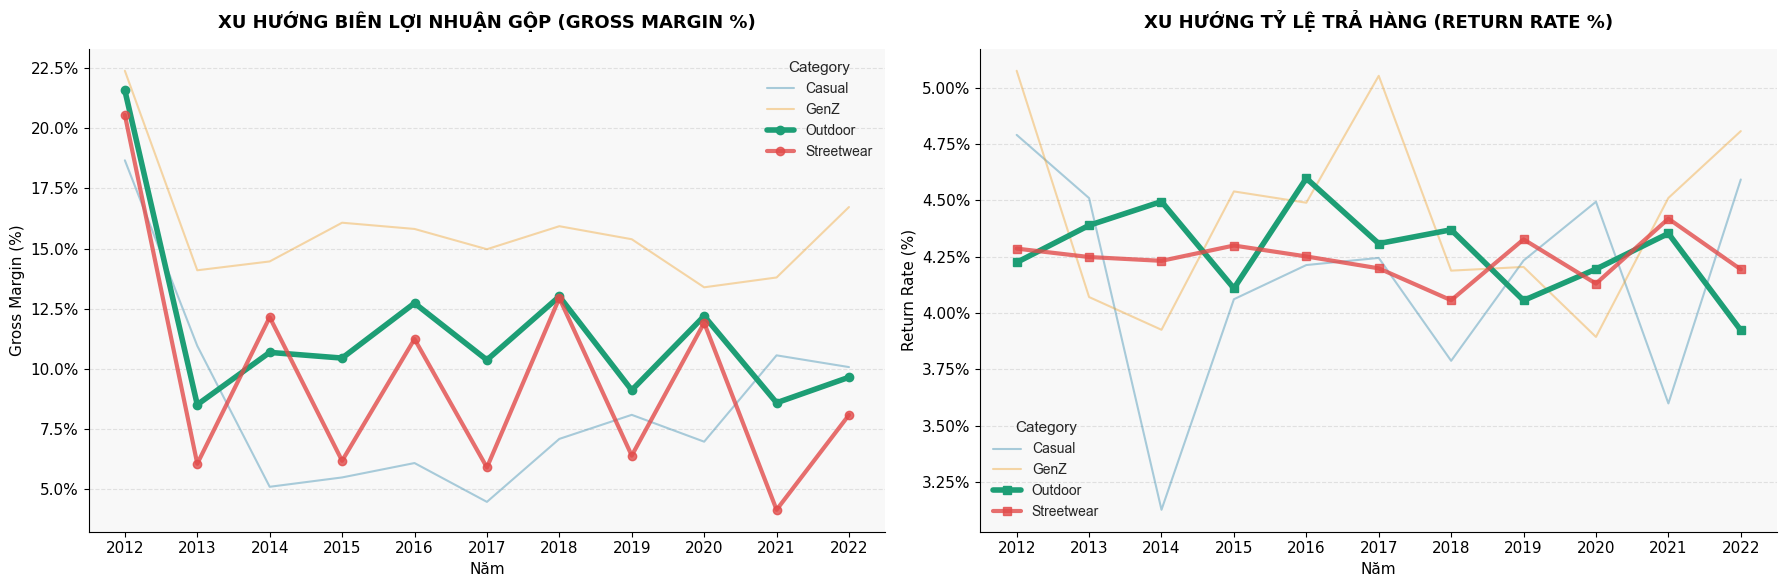

In [13]:
# =====================================================================
# CELL 4: THE TREND - THEO DÕI MARGIN VÀ RETURN RATE QUA 10 NĂM
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

print("🔄 Đang xử lý xu hướng Margin & Return Rate theo từng năm...")

# ---------------------------------------------------------------------
# 1. TÍNH MARGIN THEO NĂM
# ---------------------------------------------------------------------
orders_v = orders[orders['order_status'] == 'delivered'].copy()
orders_v['year'] = pd.to_datetime(orders_v['order_date']).dt.year

items_v = order_items[order_items['order_id'].isin(orders_v['order_id'])].copy()
items_v = items_v.merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')
items_v = items_v.merge(orders_v[['order_id', 'year']], on='order_id', how='left')

items_v['net_revenue'] = (items_v['unit_price'] * items_v['quantity']) - items_v['discount_amount'].fillna(0)
items_v['total_cogs'] = items_v['cogs'] * items_v['quantity']

margin_yr = items_v.groupby(['year', 'category']).agg(
    total_net_rev=('net_revenue', 'sum'),
    total_cogs=('total_cogs', 'sum')
).reset_index()

margin_yr['gross_margin_pct'] = ((margin_yr['total_net_rev'] - margin_yr['total_cogs']) / margin_yr['total_net_rev']) * 100

# ---------------------------------------------------------------------
# 2. TÍNH RETURN RATE THEO NĂM (Dựa trên năm đặt hàng để chuẩn Cohort)
# ---------------------------------------------------------------------
ret_merged = returns.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
ret_merged['year'] = pd.to_datetime(ret_merged['order_date']).dt.year
ret_merged = ret_merged.merge(products[['product_id', 'category']], on='product_id', how='left')

ret_yr = ret_merged.groupby(['year', 'category'])['return_quantity'].sum().reset_index(name='returned_qty')
sold_yr = items_v.groupby(['year', 'category'])['quantity'].sum().reset_index(name='sold_qty')

rr_yr = sold_yr.merge(ret_yr, on=['year', 'category'], how='left').fillna(0)
rr_yr['return_rate_pct'] = (rr_yr['returned_qty'] / rr_yr['sold_qty']) * 100

# ---------------------------------------------------------------------
# 3. VẼ BIỂU ĐỒ SO SÁNH
# ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
sns.set_style("white")

colors = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
linewidths = {'Outdoor': 4, 'Streetwear': 3, 'Casual': 1.5, 'GenZ': 1.5}
alphas = {'Outdoor': 1.0, 'Streetwear': 0.8, 'Casual': 0.4, 'GenZ': 0.4}

# --- Trái: GROSS MARGIN TREND ---
for cat in margin_yr['category'].unique():
    sub = margin_yr[margin_yr['category'] == cat]
    ax1.plot(sub['year'], sub['gross_margin_pct'], marker='o' if cat in ['Outdoor', 'Streetwear'] else None,
             color=colors.get(cat, '#888780'), linewidth=linewidths.get(cat, 1.5), 
             alpha=alphas.get(cat, 0.4), label=cat)

ax1.set_title('XU HƯỚNG BIÊN LỢI NHUẬN GỘP (GROSS MARGIN %)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Gross Margin (%)')
ax1.set_xlabel('Năm')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.set_xticks(margin_yr['year'].unique())
ax1.legend(title='Category')

# --- Phải: RETURN RATE TREND ---
for cat in rr_yr['category'].unique():
    sub = rr_yr[rr_yr['category'] == cat]
    ax2.plot(sub['year'], sub['return_rate_pct'], marker='s' if cat in ['Outdoor', 'Streetwear'] else None,
             color=colors.get(cat, '#888780'), linewidth=linewidths.get(cat, 1.5), 
             alpha=alphas.get(cat, 0.4), label=cat)

ax2.set_title('XU HƯỚNG TỶ LỆ TRẢ HÀNG (RETURN RATE %)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Return Rate (%)')
ax2.set_xlabel('Năm')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_xticks(rr_yr['year'].unique())
ax2.legend(title='Category')

sns.despine()
plt.tight_layout()
plt.show()

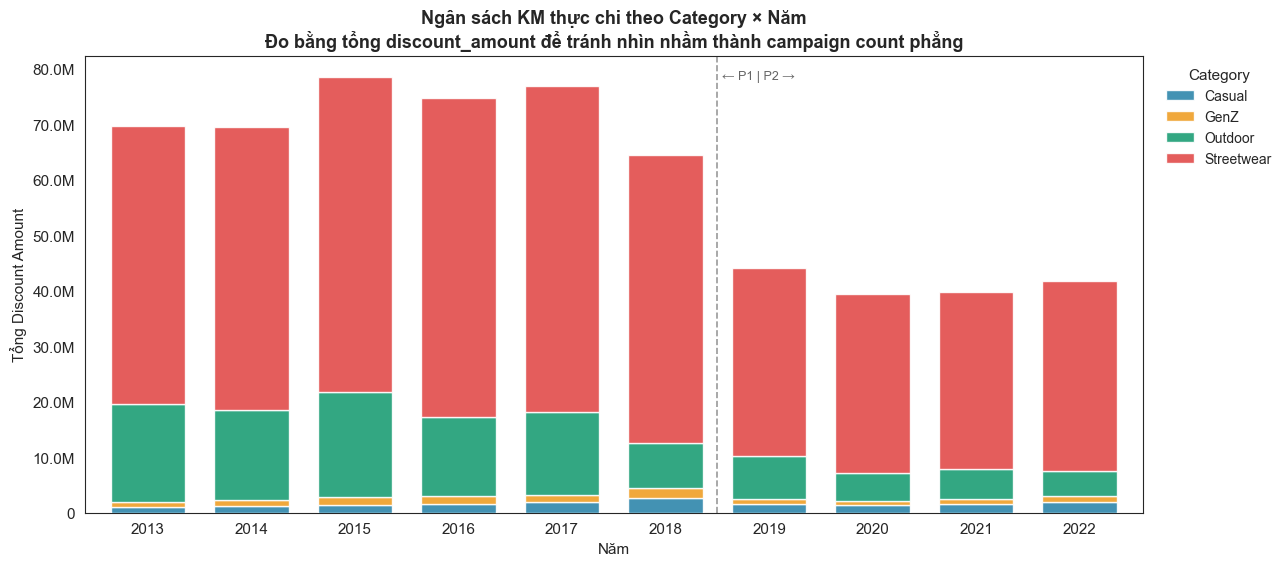

Campaign gắn category theo promotions.csv (chỉ để đối chiếu):
applicable_category  Outdoor  Streetwear
start_date                              
2013-01-31                 1           0
2013-07-30                 0           1
2015-01-30                 1           0
2015-07-30                 0           1
2017-01-30                 1           0


In [13]:
# =====================================================================
# CELL A: NGÂN SÁCH KM THỰC CHI THEO CATEGORY × NĂM
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')
promotions = pd.read_csv(INPUT_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['year'] = orders_delivered['order_date'].dt.year

# Dùng discount_amount thực chi thay vì số campaign, vì promotions.csv có rất ít campaign gắn category và mỗi năm gần như cân bằng 1-1.
items_promo = (
    order_items
    .merge(orders_delivered[['order_id', 'year']], on='order_id', how='inner')
    .merge(products[['product_id', 'category']], on='product_id', how='left')
)
items_promo = items_promo[(items_promo['discount_amount'].fillna(0) > 0) | (items_promo['promo_id'].notna())].copy()

budget_by_cat_yr = (
    items_promo
    .groupby(['year', 'category'])
    .agg(total_discount=('discount_amount', 'sum'), n_orders=('order_id', 'nunique'))
    .reset_index()
)

budget_pivot = budget_by_cat_yr.pivot(index='year', columns='category', values='total_discount').fillna(0)
budget_pivot = budget_pivot.sort_index()

# Stacked bar: tổng discount amount theo category
colors_map = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
bar_colors = [colors_map.get(c, '#888780') for c in budget_pivot.columns]

fig, ax = plt.subplots(figsize=(13, 5.8))
budget_pivot.plot(kind='bar', stacked=True, ax=ax, color=bar_colors, alpha=0.9, width=0.72, zorder=3)

years = list(budget_pivot.index)
if 2018 in years:
    x_pos = years.index(2018) + 0.5
    ax.axvline(x=x_pos, color='#999', linestyle='--', linewidth=1.2)
    ax.text(x_pos + 0.05, ax.get_ylim()[1] * 0.95, '← P1 | P2 →', fontsize=9, color='#666')

ax.set_title('Ngân sách KM thực chi theo Category × Năm\n'
             'Đo bằng tổng discount_amount để tránh nhìn nhầm thành campaign count phẳng', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Tổng Discount Amount')
ax.set_xticklabels(budget_pivot.index, rotation=0)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if abs(v) >= 1e6 else f'{v:,.0f}'))

plt.tight_layout()
plt.show()

print('Campaign gắn category theo promotions.csv (chỉ để đối chiếu):')
print(promotions[promotions['applicable_category'].notna()].groupby(['start_date', 'applicable_category']).size().unstack(fill_value=0).head().to_string())

Customer-level promo dependency summary:
       total_orders  promo_orders  promo_penetration_pct  discount_ratio_pct  promo_dependency_score
count     85,115.00     85,115.00              85,115.00           85,115.00               85,115.00
mean           6.07          2.33                  38.32                4.95                   28.31
std            7.04          2.97                  32.45                5.32                   24.08
min            1.00          0.00                   0.00                0.00                    0.00
25%            1.00          0.00                   0.00                0.00                    0.00
50%            3.00          1.00                  35.00                3.54                   26.07
75%            8.00          3.00                  50.00                7.55                   39.07
max           93.00         40.00                 100.00               20.00                   76.00

Top 15 customers by promo dependency score:
 cust

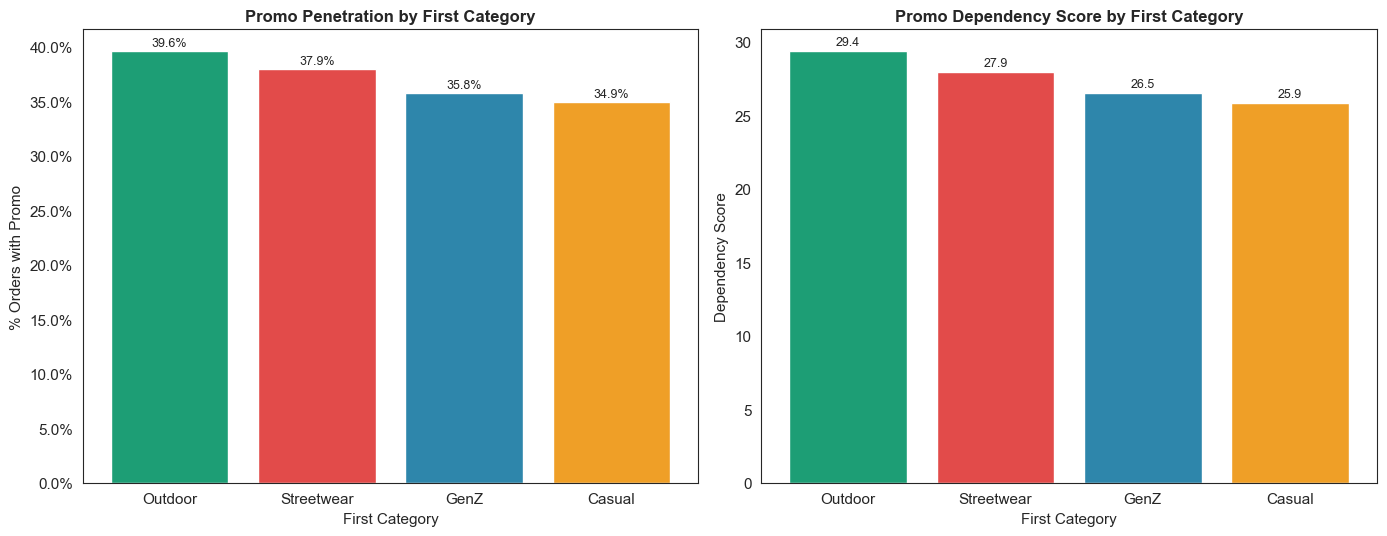


Category-level promo dependency:
first_category  customers  avg_promo_penetration  avg_discount_ratio  avg_dependency_score
       Outdoor      29338                  39.62                5.50                 29.38
    Streetwear      49211                  37.93                4.63                 27.94
          GenZ       4168                  35.76                4.88                 26.50
        Casual       2398                  34.91                4.75                 25.86


In [14]:
# =====================================================================
# CELL B: PROMO DEPENDENCY — Khách nào phụ thuộc khuyến mãi nhất?
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['year'] = orders_delivered['order_date'].dt.year

# Gắn customer_id để đo dependency ở mức khách hàng
items_dep = (
    order_items
    .merge(orders_delivered[['order_id', 'customer_id', 'order_date', 'year']], on='order_id', how='inner')
    .merge(products[['product_id', 'category']], on='product_id', how='left')
)

# Định nghĩa đơn hàng có promo: có discount_amount > 0 hoặc promo_id không null
items_dep['gross_item'] = items_dep['unit_price'] * items_dep['quantity']
items_dep['has_promo'] = ((items_dep['discount_amount'].fillna(0) > 0) | (items_dep['promo_id'].notna())).astype(int)

# Gom cấp order trước để tránh double-count item trong cùng đơn
order_level = (
    items_dep
    .groupby(['order_id', 'customer_id', 'order_date', 'year'])
    .agg(
        promo_order=('has_promo', 'max'),
        order_gross=('gross_item', 'sum'),
        order_discount=('discount_amount', 'sum')
    )
    .reset_index()
)
order_level['order_discount'] = order_level['order_discount'].fillna(0)
order_level['promo_order_rate'] = order_level['promo_order']
order_level['discount_ratio'] = np.where(
    order_level['order_gross'] > 0,
    order_level['order_discount'] / order_level['order_gross'] * 100,
    0
)

# Customer-level promo dependency
customer_dep = (
    order_level
    .groupby('customer_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        promo_orders=('promo_order', 'sum'),
        total_gross=('order_gross', 'sum'),
        total_discount=('order_discount', 'sum')
    )
    .reset_index()
)
customer_dep['promo_penetration_pct'] = np.where(
    customer_dep['total_orders'] > 0,
    customer_dep['promo_orders'] / customer_dep['total_orders'] * 100,
    0
)
customer_dep['discount_ratio_pct'] = np.where(
    customer_dep['total_gross'] > 0,
    customer_dep['total_discount'] / customer_dep['total_gross'] * 100,
    0
)

# Một score đơn giản để rank: nặng về penetration, có thêm discount ratio
customer_dep['promo_dependency_score'] = (
    customer_dep['promo_penetration_pct'] * 0.7 +
    customer_dep['discount_ratio_pct'] * 0.3
)

# Gắn first_category của đơn đầu tiên để xem dependency theo tệp mua ban đầu
first_orders = orders_delivered.sort_values('order_date').groupby('customer_id').first().reset_index()
first_items = (
    order_items[order_items['order_id'].isin(first_orders['order_id'])]
    .merge(products[['product_id', 'category']], on='product_id', how='left')
)
first_cat = (
    first_items
    .groupby('order_id')['category']
    .first()
    .reset_index(name='first_category')
)

customer_dep = (
    customer_dep
    .merge(first_orders[['customer_id', 'order_id']], on='customer_id', how='left')
    .merge(first_cat, on='order_id', how='left')
)

print('Customer-level promo dependency summary:')
print(customer_dep[['total_orders', 'promo_orders', 'promo_penetration_pct', 'discount_ratio_pct', 'promo_dependency_score']].describe().round(2).to_string())

print('\nTop 15 customers by promo dependency score:')
show_cols = ['customer_id', 'first_category', 'total_orders', 'promo_orders', 'promo_penetration_pct', 'discount_ratio_pct', 'promo_dependency_score']
print(customer_dep.sort_values('promo_dependency_score', ascending=False)[show_cols].head(15).to_string(index=False))

# So sánh theo first_category
cat_dep = (
    customer_dep
    .groupby('first_category')
    .agg(
        customers=('customer_id', 'nunique'),
        avg_promo_penetration=('promo_penetration_pct', 'mean'),
        avg_discount_ratio=('discount_ratio_pct', 'mean'),
        avg_dependency_score=('promo_dependency_score', 'mean')
    )
    .reset_index()
    .sort_values('avg_dependency_score', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax1 = axes[0]
bars = ax1.bar(cat_dep['first_category'], cat_dep['avg_promo_penetration'], color=['#1D9E75', '#E24B4A', '#2E86AB', '#EF9F27'])
ax1.set_title('Promo Penetration by First Category', fontsize=12)
ax1.set_xlabel('First Category')
ax1.set_ylabel('% Orders with Promo')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(bars, cat_dep['avg_promo_penetration']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax2 = axes[1]
bars2 = ax2.bar(cat_dep['first_category'], cat_dep['avg_dependency_score'], color=['#1D9E75', '#E24B4A', '#2E86AB', '#EF9F27'])
ax2.set_title('Promo Dependency Score by First Category', fontsize=12)
ax2.set_xlabel('First Category')
ax2.set_ylabel('Dependency Score')
for bar, val in zip(bars2, cat_dep['avg_dependency_score']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('\nCategory-level promo dependency:')
print(cat_dep.to_string(index=False))

Promo penetration by category and year:
 year   category  total_orders  promo_orders  promo_penetration_pct
 2012     Casual           511             0                   0.00
 2012       GenZ          1022             0                   0.00
 2012    Outdoor         11742             0                   0.00
 2012 Streetwear         12533             0                   0.00
 2013     Casual          1238           438                  35.38
 2013       GenZ          2705           943                  34.86
 2013    Outdoor         24796         11897                  47.98
 2013 Streetwear         33238         15340                  46.15
 2014     Casual          1392           490                  35.20
 2014       GenZ          2914           994                  34.11
 2014    Outdoor         25060         10550                  42.10
 2014 Streetwear         35724         11852                  33.18
 2015     Casual          1753           650                  37.08
 2015   

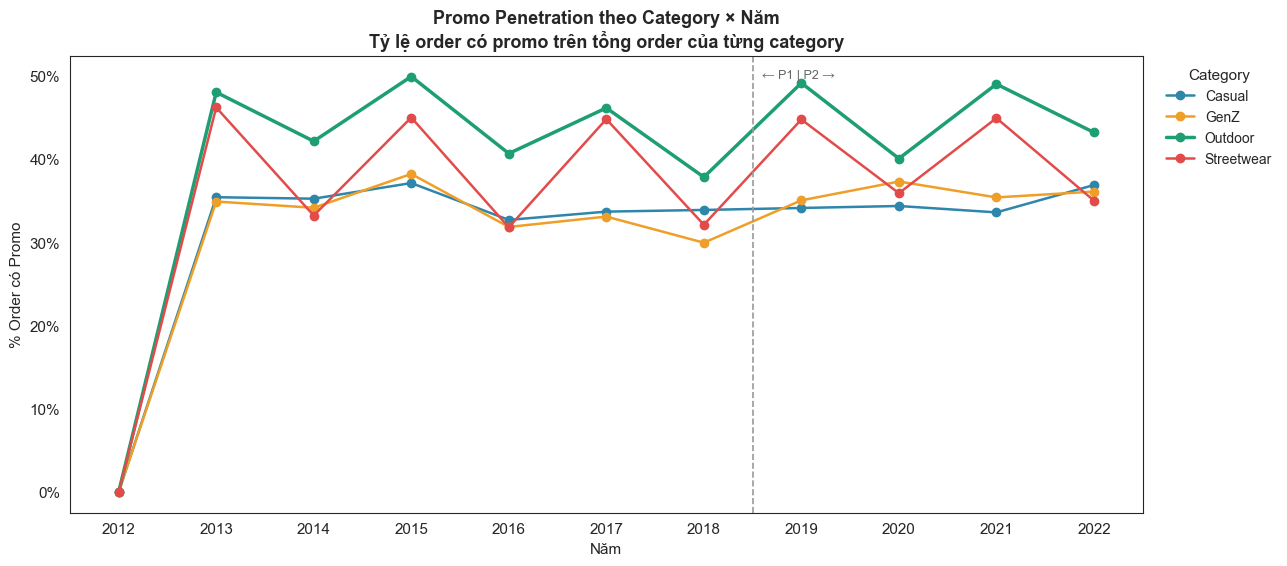

In [18]:
# =====================================================================
# CELL C: PROMO PENETRATION — Tỷ lệ đơn có promo theo Category × Năm
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['year'] = orders_delivered['order_date'].dt.year

# Quy về cấp order-category-year: một order có thể xuất hiện ở nhiều category nếu chứa nhiều category khác nhau.
# Promo penetration = số order có promo trong category / tổng số order có category theo năm.
items_pen = (
    order_items
    .merge(orders_delivered[['order_id', 'order_date', 'year']], on='order_id', how='inner')
    .merge(products[['product_id', 'category']], on='product_id', how='left')
)
items_pen['has_promo'] = ((items_pen['discount_amount'].fillna(0) > 0) | (items_pen['promo_id'].notna())).astype(int)

order_cat_level = (
    items_pen
    .groupby(['order_id', 'year', 'category'])
    .agg(promo_order=('has_promo', 'max'))
    .reset_index()
)

penetration_cat_year = (
    order_cat_level
    .groupby(['year', 'category'])
    .agg(
        total_orders=('order_id', 'nunique'),
        promo_orders=('promo_order', 'sum')
    )
    .reset_index()
)
penetration_cat_year['promo_penetration_pct'] = np.where(
    penetration_cat_year['total_orders'] > 0,
    penetration_cat_year['promo_orders'] / penetration_cat_year['total_orders'] * 100,
    0
)

# Pivot để vẽ stacked / line
penetration_pivot = penetration_cat_year.pivot(index='year', columns='category', values='promo_penetration_pct').fillna(0)
penetration_pivot = penetration_pivot.sort_index()

print('Promo penetration by category and year:')
print(penetration_cat_year.sort_values(['year', 'category']).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5.8))
colors_map = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}

for col in penetration_pivot.columns:
    ax.plot(
        penetration_pivot.index,
        penetration_pivot[col],
        color=colors_map.get(col, '#888780'),
        linewidth=2.5 if col == 'Outdoor' else 1.8,
        marker='o',
        label=col
    )

ax.axvline(x=2018.5, color='#999', linestyle='--', linewidth=1.2)
ax.text(2018.6, ax.get_ylim()[1] * 0.95, '← P1 | P2 →', fontsize=9, color='#666')

ax.set_title('Promo Penetration theo Category × Năm\n'
             'Tỷ lệ order có promo trên tổng order của từng category', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('% Order có Promo')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(penetration_pivot.index)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


Summary (selected years) — Outdoor vs Streetwear:
 year   category  total_orders  promo_orders  avg_discount_per_promo_order  discount_pct_of_gross  promo_penetration_pct
 2012    Outdoor         11742             0                           NaN                   0.00                   0.00
 2012 Streetwear         12533             0                           NaN                   0.00                   0.00
 2013    Outdoor         24796         11897                      1,488.61                   6.75                  47.98
 2013 Streetwear         33238         15340                      3,255.88                   4.88                  46.15
 2014    Outdoor         25060         10550                      1,540.24                   5.73                  42.10
 2014 Streetwear         35724         11852                      4,301.00                   4.36                  33.18
 2015    Outdoor         23217         11578                      1,624.89                   6.92     

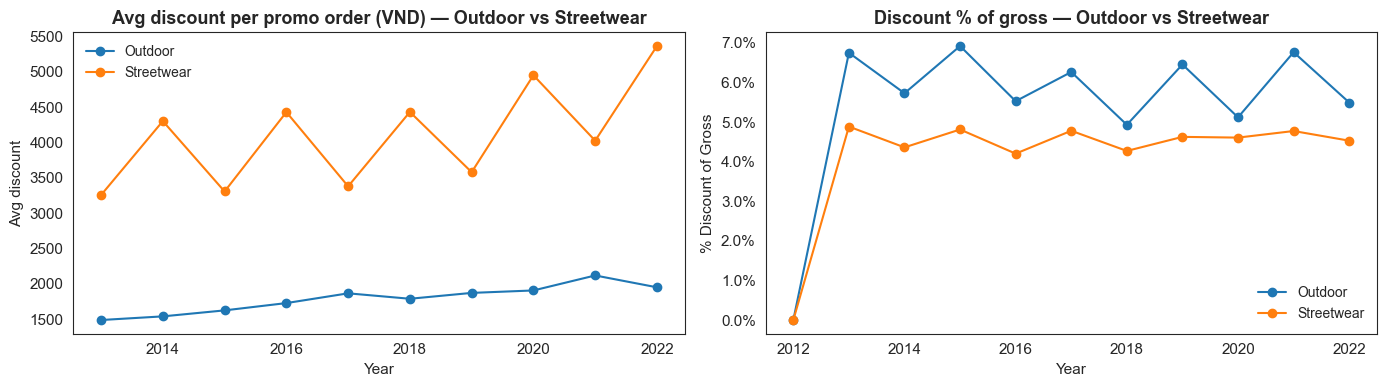


Budget share by category (last available year):
  category  total_discount  budget_share
Streetwear   34,258,980.61          0.82
   Outdoor    4,454,588.27          0.11
    Casual    1,987,647.85          0.05
      GenZ    1,027,248.06          0.03


In [20]:
# =====================================================================
# CELL D: QUICK COMPARE — Outdoor vs Streetwear (avg discount, % of gross, penetration, budget share)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['year'] = orders_delivered['order_date'].dt.year

items = (
    order_items
    .merge(orders_delivered[['order_id','year','order_date','customer_id']], on='order_id', how='inner')
    .merge(products[['product_id','category']], on='product_id', how='left')
)
items['has_promo'] = ((items['discount_amount'].fillna(0) > 0) | items['promo_id'].notna()).astype(int)
items['gross_item'] = items['unit_price'] * items['quantity']

# aggregate về cấp order-category
order_cat = (
    items
    .groupby(['order_id','year','category'])
    .agg(
        promo_order=('has_promo','max'),
        order_gross=('gross_item','sum'),
        order_discount=('discount_amount','sum')
    ).reset_index()
 )

summary = (
    order_cat
    .groupby(['year','category'])
    .agg(
        total_orders=('order_id','nunique'),
        promo_orders=('promo_order','sum'),
        total_gross=('order_gross','sum'),
        total_discount=('order_discount','sum')
    ).reset_index()
 )

summary['avg_discount_per_promo_order'] = summary['total_discount'] / summary['promo_orders']
summary['discount_pct_of_gross'] = 100 * summary['total_discount'] / summary['total_gross']
summary['promo_penetration_pct'] = 100 * summary['promo_orders'] / summary['total_orders']

# budget share per year
budget_share = summary.groupby('year').apply(
    lambda df: df.assign(budget_share = df['total_discount'] / df['total_discount'].sum())
).reset_index(drop=True)

# Focus on Outdoor vs Streetwear
focus = summary[summary['category'].isin(['Outdoor','Streetwear'])].copy()
focus = focus.sort_values(['year','category'])

print('\nSummary (selected years) — Outdoor vs Streetwear:')
print(focus[['year','category','total_orders','promo_orders','avg_discount_per_promo_order','discount_pct_of_gross','promo_penetration_pct']].round(2).to_string(index=False))

# Quick plots: avg_discount_per_promo_order and discount_pct_of_gross over years
fig, axes = plt.subplots(1,2,figsize=(14,4))
ax = axes[0]
for cat, grp in focus.groupby('category'):
    ax.plot(grp['year'], grp['avg_discount_per_promo_order'], marker='o', label=cat)
ax.set_title('Avg discount per promo order (VND) — Outdoor vs Streetwear')
ax.set_xlabel('Year')
ax.set_ylabel('Avg discount')
ax.legend()

ax = axes[1]
for cat, grp in focus.groupby('category'):
    ax.plot(grp['year'], grp['discount_pct_of_gross'], marker='o', label=cat)
ax.set_title('Discount % of gross — Outdoor vs Streetwear')
ax.set_xlabel('Year')
ax.set_ylabel('% Discount of Gross')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()

plt.tight_layout()
plt.show()

print('\nBudget share by category (last available year):')
last_year = budget_share['year'].max()
print(budget_share[budget_share['year']==last_year][['category','total_discount','budget_share']].sort_values('budget_share',ascending=False).round(3).to_string(index=False))

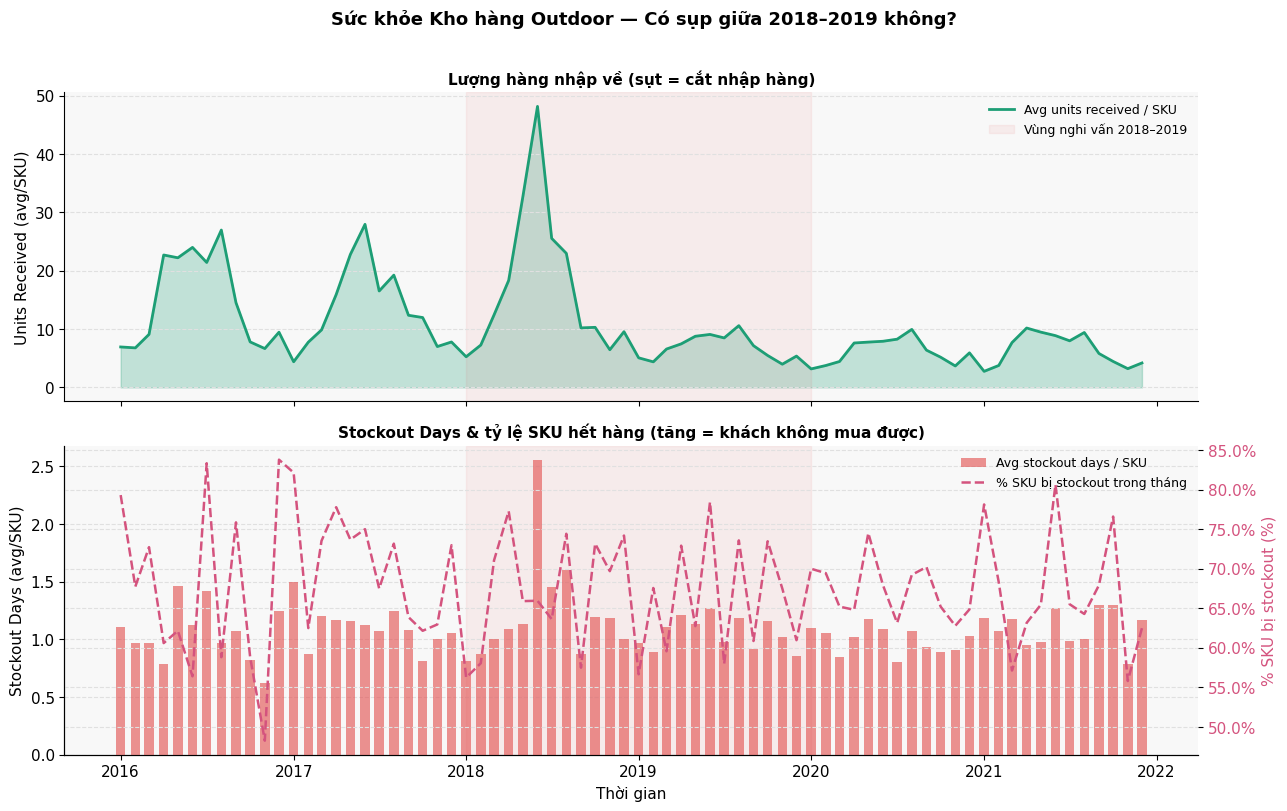

In [5]:
# =====================================================================
# CELL B: KHO HÀNG SỤP — Inventory Outdoor giai đoạn 2016–2021
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

inventory = pd.read_csv(INPUT_DIR / 'inventory.csv', parse_dates=['snapshot_date'])

outdoor_inv = inventory[
    (inventory['category'] == 'GenZ') &
    (inventory['year'].between(2016, 2021))
].copy()

# Aggregate theo tháng để giảm noise từng SKU
monthly = (
    outdoor_inv.groupby(['year', 'month'])
    .agg(
        avg_stockout_days=('stockout_days', 'mean'),
        avg_units_received=('units_received', 'mean'),
        stockout_flag_rate=('stockout_flag', 'mean'),   # % tháng bị stockout
        n_skus=('product_id', 'nunique')
    )
    .reset_index()
)
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
monthly = monthly.sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Sức khỏe Kho hàng Outdoor — Có sụp giữa 2018–2019 không?',
             fontsize=13, fontweight='bold', y=1.01)

C_OUT = '#1D9E75'
C_WARN = '#E24B4A'

# --- Trên: Units received (lượng hàng nhập) ---
ax1 = axes[0]
ax1.fill_between(monthly['date'], monthly['avg_units_received'],
                 alpha=0.25, color=C_OUT)
ax1.plot(monthly['date'], monthly['avg_units_received'],
         color=C_OUT, linewidth=2, label='Avg units received / SKU')
ax1.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2019-12-31'),
            alpha=0.07, color=C_WARN, label='Vùng nghi vấn 2018–2019')
ax1.set_ylabel('Units Received (avg/SKU)')
ax1.legend(fontsize=9)
ax1.set_title('Lượng hàng nhập về (sụt = cắt nhập hàng)', fontsize=11)

# --- Dưới: Stockout days + stockout flag rate ---
ax2 = axes[1]
ax2.bar(monthly['date'], monthly['avg_stockout_days'],
        width=20, color=C_WARN, alpha=0.6, label='Avg stockout days / SKU', zorder=3)
ax2_twin = ax2.twinx()
ax2_twin.plot(monthly['date'], monthly['stockout_flag_rate'] * 100,
              color='#D4537E', linewidth=1.8, linestyle='--',
              label='% SKU bị stockout trong tháng')
ax2_twin.set_ylabel('% SKU bị stockout (%)', color='#D4537E')
ax2_twin.tick_params(axis='y', labelcolor='#D4537E')
ax2_twin.yaxis.set_major_formatter(mticker.PercentFormatter())

ax2.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2019-12-31'),
            alpha=0.07, color=C_WARN)
ax2.set_ylabel('Stockout Days (avg/SKU)')
ax2.set_xlabel('Thời gian')
ax2.set_title('Stockout Days & tỷ lệ SKU hết hàng (tăng = khách không mua được)', fontsize=11)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

🔄 Đang tính toán chu kỳ bán hàng theo tháng...


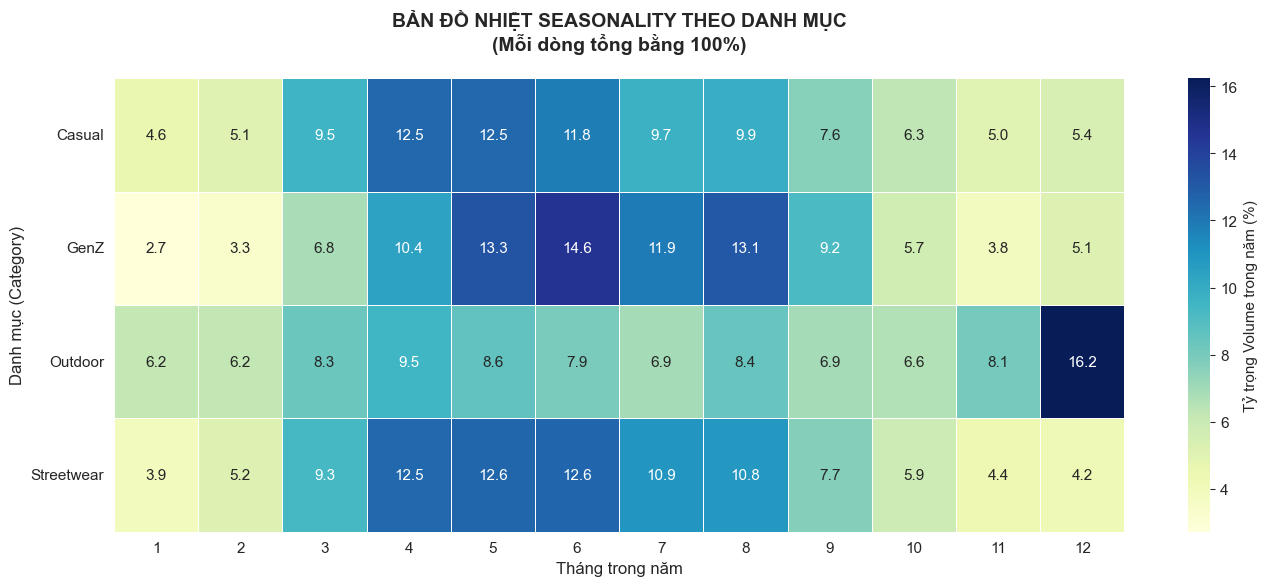


--- TOP 2 THÁNG BÁN CHẠY NHẤT CỦA TỪNG DANH MỤC ---
🔸 Casual: Tháng 5 (12.5%) và Tháng 4 (12.5%)
🔸 GenZ: Tháng 6 (14.6%) và Tháng 5 (13.3%)
🔸 Outdoor: Tháng 12 (16.2%) và Tháng 4 (9.5%)
🔸 Streetwear: Tháng 5 (12.6%) và Tháng 6 (12.6%)


In [9]:
# =====================================================================
# PHÂN TÍCH TÍNH CHU KỲ (SEASONALITY) THEO DANH MỤC
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

print("🔄 Đang tính toán chu kỳ bán hàng theo tháng...")
orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')
# 1. TIỀN XỬ LÝ: Lấy tháng từ đơn hàng giao thành công
orders_v = orders[orders['order_status'] == 'delivered'].copy()
orders_v['order_date'] = pd.to_datetime(orders_v['order_date'])
orders_v['month'] = orders_v['order_date'].dt.month
orders_v['year'] = orders_v['order_date'].dt.year

# 2. MERGE DỮ LIỆU ĐỂ LẤY CATEGORY VÀ QUANTITY
items_v = order_items[order_items['order_id'].isin(orders_v['order_id'])].copy()
items_v = items_v.merge(orders_v[['order_id', 'month', 'year']], on='order_id')
items_v = items_v.merge(products[['product_id', 'category']], on='product_id', how='left')

# 3. TÍNH TỔNG VOLUME THEO THÁNG VÀ CATEGORY
# Gom nhóm để xem mỗi tháng bán được bao nhiêu units cho từng category
seasonal_vol = items_v.groupby(['category', 'month'])['quantity'].sum().unstack().fillna(0)

# 4. CHUẨN HÓA THÀNH TỶ TRỌNG % THEO TỪNG CATEGORY (Row-wise percentage)
# Ví dụ: Tổng Outdoor cả năm là 100%, thì tháng 1 chiếm bao nhiêu %?
seasonal_pct = seasonal_vol.div(seasonal_vol.sum(axis=1), axis=0) * 100

# 5. VẼ BẢN ĐỒ NHIỆT (HEATMAP)
plt.figure(figsize=(14, 6))
sns.set_style("white")

# Sử dụng cmap YlGnBu (Vàng -> Xanh lam). Màu càng đậm thì tháng đó bán càng chạy.
ax = sns.heatmap(seasonal_pct, annot=True, fmt=".1f", cmap="YlGnBu", 
                 linewidths=.5, cbar_kws={'label': 'Tỷ trọng Volume trong năm (%)'})

plt.title('BẢN ĐỒ NHIỆT SEASONALITY THEO DANH MỤC\n(Mỗi dòng tổng bằng 100%)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tháng trong năm', fontsize=12)
plt.ylabel('Danh mục (Category)', fontsize=12)

# Xoay nhãn trục Y để dễ đọc
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# (Optional) Tính thêm: Đóng góp của các tháng Peak vào Tổng doanh thu
# ---------------------------------------------------------------------
# In ra top 2 tháng bán chạy nhất của từng category để dễ báo cáo
print("\n--- TOP 2 THÁNG BÁN CHẠY NHẤT CỦA TỪNG DANH MỤC ---")
for cat in seasonal_pct.index:
    top_months = seasonal_pct.loc[cat].nlargest(2)
    print(f"🔸 {cat}: Tháng {top_months.index[0]} ({top_months.iloc[0]:.1f}%) và Tháng {top_months.index[1]} ({top_months.iloc[1]:.1f}%)")

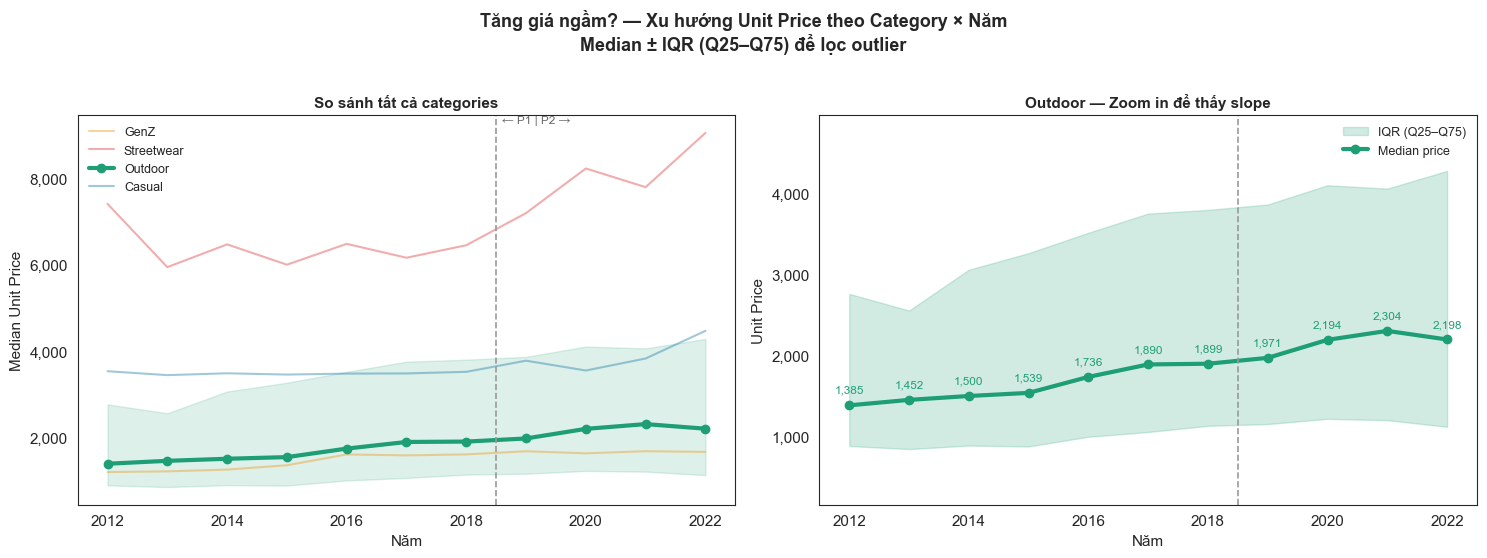

In [16]:
# =====================================================================
# CELL C: TĂNG GIÁ NGẦM — Unit price trend của SKU Outdoor qua các năm
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year'] = orders_d['order_date'].dt.year

# Join để lấy category
items = (
    order_items
    .merge(orders_d[['order_id', 'year']], on='order_id', how='inner')
    .merge(products[['product_id', 'category']], on='product_id', how='left')
)

# Tính median & percentile giá theo category × year (median ổn hơn mean vì ít bị outlier)
def price_stats(df):
    return pd.Series({
        'p25': df['unit_price'].quantile(0.25),
        'median': df['unit_price'].median(),
        'p75': df['unit_price'].quantile(0.75),
    })

price_yr = (
    items.groupby(['year', 'category'])
    .apply(price_stats)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Tăng giá ngầm? — Xu hướng Unit Price theo Category × Năm\n'
             'Median ± IQR (Q25–Q75) để lọc outlier',
             fontsize=13, fontweight='bold', y=1.01)

colors_map = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
categories = items['category'].dropna().unique()

# --- Trái: tất cả categories ---
ax1 = axes[0]
for cat in categories:
    sub = price_yr[price_yr['category'] == cat].sort_values('year')
    lw = 3 if cat == 'Outdoor' else 1.5
    alpha = 1.0 if cat == 'Outdoor' else 0.45
    color = colors_map.get(cat, '#888780')
    ax1.plot(sub['year'], sub['median'], color=color, linewidth=lw,
             alpha=alpha, label=cat, marker='o' if cat == 'Outdoor' else None)
    if cat == 'Outdoor':
        ax1.fill_between(sub['year'], sub['p25'], sub['p75'],
                         alpha=0.15, color=color, label='_nolegend_')

ax1.axvline(x=2018.5, color='#999', linestyle='--', linewidth=1.2)
ax1.text(2018.6, ax1.get_ylim()[1] * 0.98, '← P1 | P2 →', fontsize=8.5, color='#666')
ax1.set_title('So sánh tất cả categories', fontsize=11)
ax1.set_xlabel('Năm')
ax1.set_ylabel('Median Unit Price')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.legend(fontsize=9)

# --- Phải: chỉ Outdoor — zoom vào để thấy rõ slope ---
ax2 = axes[1]
out_sub = price_yr[price_yr['category'] == 'Outdoor'].sort_values('year')
ax2.fill_between(out_sub['year'], out_sub['p25'], out_sub['p75'],
                 alpha=0.2, color='#1D9E75', label='IQR (Q25–Q75)')
ax2.plot(out_sub['year'], out_sub['median'], color='#1D9E75',
         linewidth=3, marker='o', label='Median price')

# Annotate từng điểm
for _, row in out_sub.iterrows():
    ax2.annotate(f"{row['median']:,.0f}",
                 xy=(row['year'], row['median']),
                 xytext=(0, 9), textcoords='offset points',
                 ha='center', fontsize=8.5, color='#1D9E75')

ax2.axvline(x=2018.5, color='#999', linestyle='--', linewidth=1.2)
ax2.set_title('Outdoor — Zoom in để thấy slope', fontsize=11)
ax2.set_xlabel('Năm')
ax2.set_ylabel('Unit Price')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

# Zoom trục Y: chỉ hiển thị range thực tế
y_pad = (out_sub['p75'].max() - out_sub['p25'].min()) * 0.2
ax2.set_ylim(out_sub['p25'].min() - y_pad, out_sub['p75'].max() + y_pad)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

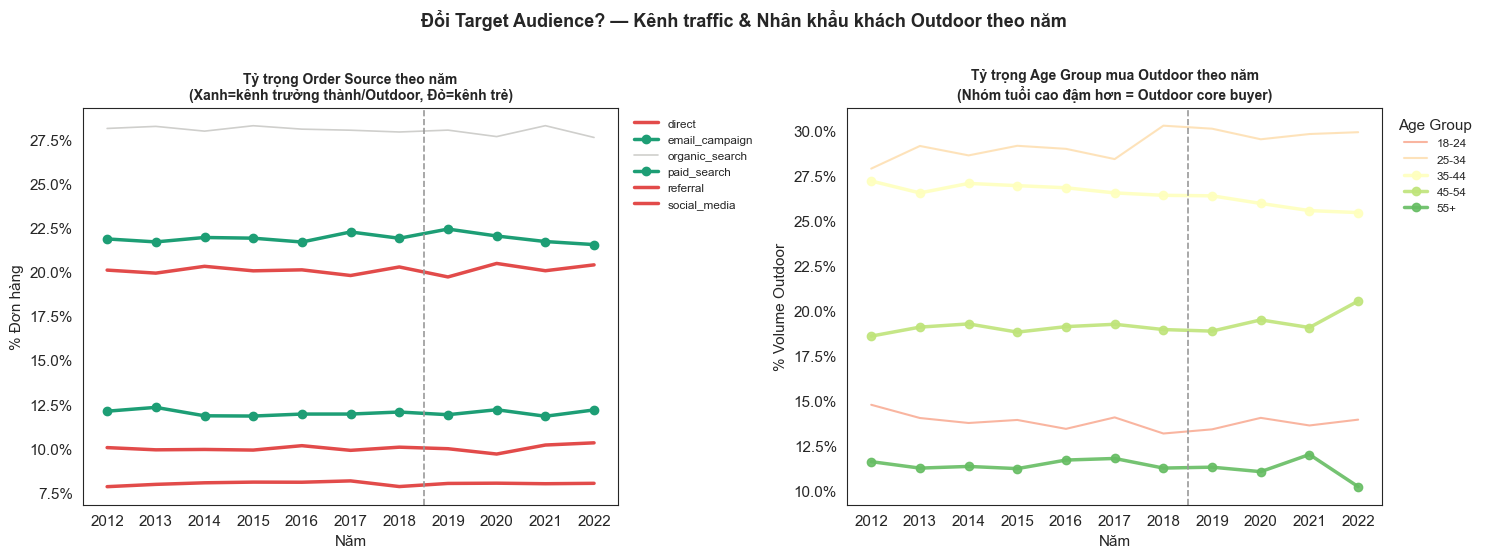

In [17]:
# =====================================================================
# CELL D: ĐỔI TARGET AUDIENCE — order_source × age_group × category theo năm
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

orders    = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
customers = pd.read_csv(INPUT_DIR / 'customers.csv')
products  = pd.read_csv(INPUT_DIR / 'products.csv')

orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year'] = orders_d['order_date'].dt.year

# Tính tỷ trọng order_source theo năm (proxy cho audience targeting)
source_yr = (
    orders_d.groupby(['year', 'order_source'])
    .size()
    .reset_index(name='n_orders')
)
source_yr['pct'] = (
    source_yr.groupby('year')['n_orders']
    .transform(lambda x: x / x.sum() * 100)
)
source_pivot = source_yr.pivot(index='year', columns='order_source', values='pct').fillna(0)

# Tỷ trọng age_group mua Outdoor theo năm
items_all = order_items.merge(orders_d[['order_id', 'year', 'customer_id']], on='order_id', how='inner')
items_all = items_all.merge(products[['product_id', 'category']], on='product_id', how='left')
items_all = items_all.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')

outdoor_age_yr = (
    items_all[items_all['category'] == 'Outdoor']
    .groupby(['year', 'age_group'])['quantity']
    .sum()
    .reset_index(name='qty')
)
outdoor_age_yr['pct'] = (
    outdoor_age_yr.groupby('year')['qty']
    .transform(lambda x: x / x.sum() * 100)
)

# Sort age_group tự nhiên
try:
    age_order = sorted(
        outdoor_age_yr['age_group'].unique(),
        key=lambda x: int(str(x).split('-')[0].replace('+','').replace('<','').strip())
    )
except Exception:
    age_order = sorted(outdoor_age_yr['age_group'].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Đổi Target Audience? — Kênh traffic & Nhân khẩu khách Outdoor theo năm',
             fontsize=13, fontweight='bold', y=1.01)

# --- Trái: order_source trend ---
ax1 = axes[0]
# Highlight kênh trưởng thành (paid_search, email) vs trẻ (social, referral)
mature_channels = [c for c in source_pivot.columns if any(k in c.lower() for k in ['paid', 'email'])]
young_channels  = [c for c in source_pivot.columns if any(k in c.lower() for k in ['social', 'referral', 'direct'])]

channel_colors = {}
for c in source_pivot.columns:
    if c in mature_channels: channel_colors[c] = '#1D9E75'
    elif c in young_channels: channel_colors[c] = '#E24B4A'
    else: channel_colors[c] = '#888780'

for col in source_pivot.columns:
    lw    = 2.5 if col in mature_channels + young_channels else 1.2
    alpha = 1.0 if col in mature_channels + young_channels else 0.4
    ax1.plot(source_pivot.index, source_pivot[col],
             color=channel_colors[col], linewidth=lw, alpha=alpha,
             label=col, marker='o' if col in mature_channels else None)

ax1.axvline(x=2018.5, color='#999', linestyle='--', linewidth=1.2)
ax1.set_title('Tỷ trọng Order Source theo năm\n'
              '(Xanh=kênh trưởng thành/Outdoor, Đỏ=kênh trẻ)', fontsize=10)
ax1.set_xlabel('Năm')
ax1.set_ylabel('% Đơn hàng')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.set_xticks(source_pivot.index)
ax1.legend(fontsize=8.5, bbox_to_anchor=(1.01, 1), loc='upper left')

# --- Phải: Age group mua Outdoor ---
ax2 = axes[1]
age_pivot = outdoor_age_yr.pivot(index='year', columns='age_group', values='pct').fillna(0)
age_pivot = age_pivot[[a for a in age_order if a in age_pivot.columns]]

age_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(age_pivot.columns)))
for i, ag in enumerate(age_pivot.columns):
    lw    = 2.5 if i >= len(age_pivot.columns) // 2 else 1.5   # nhóm tuổi cao = đậm
    alpha = 0.9 if i >= len(age_pivot.columns) // 2 else 0.5
    ax2.plot(age_pivot.index, age_pivot[ag],
             color=age_colors[i], linewidth=lw, alpha=alpha,
             label=ag, marker='o' if i >= len(age_pivot.columns) // 2 else None)

ax2.axvline(x=2018.5, color='#999', linestyle='--', linewidth=1.2)
ax2.set_title('Tỷ trọng Age Group mua Outdoor theo năm\n'
              '(Nhóm tuổi cao đậm hơn = Outdoor core buyer)', fontsize=10)
ax2.set_xlabel('Năm')
ax2.set_ylabel('% Volume Outdoor')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_xticks(age_pivot.index)
ax2.legend(fontsize=8.5, title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

🔄 Đang chạy RFM kết hợp Category Mix...


<Figure size 1200x600 with 0 Axes>

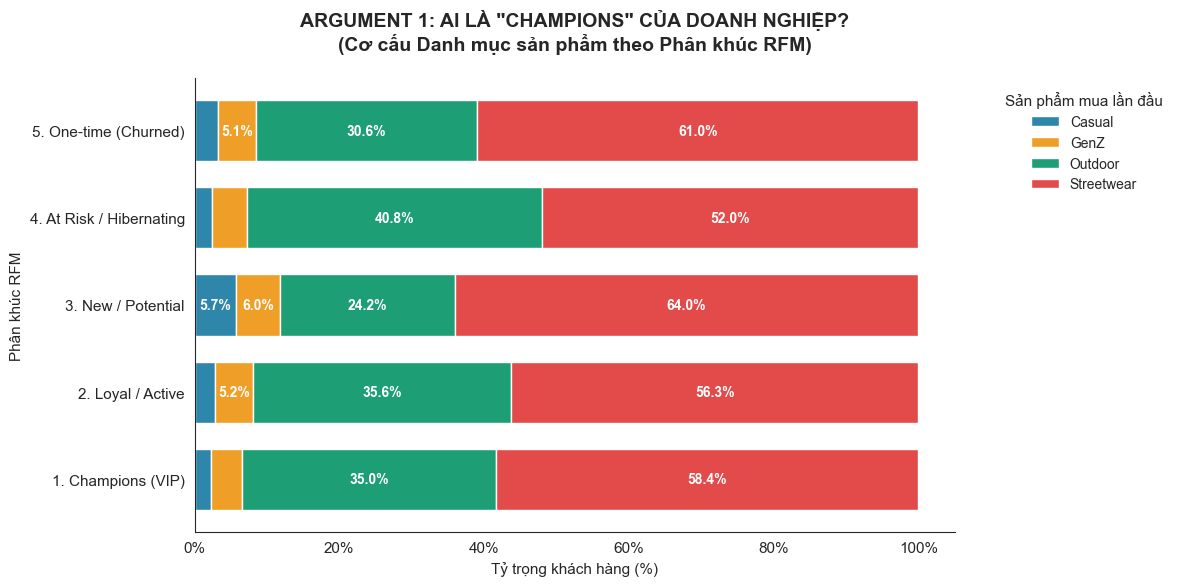

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

print("🔄 Đang chạy RFM kết hợp Category Mix...")

# 1. TÍNH RFM CƠ BẢN TÍNH ĐẾN NGÀY CUỐI CÙNG CỦA DATA
SNAPSHOT_DATE = pd.to_datetime(orders['order_date']).max()

orders_v = orders[orders['order_status'] == 'delivered'].copy()
orders_v['order_date'] = pd.to_datetime(orders_v['order_date'])

# Tính Net Revenue cho mỗi order
items_v = order_items[order_items['order_id'].isin(orders_v['order_id'])].copy()
items_v['net_rev'] = (items_v['unit_price'] * items_v['quantity']) - items_v['discount_amount'].fillna(0)
order_rev = items_v.groupby('order_id')['net_rev'].sum().reset_index()
orders_v = orders_v.merge(order_rev, on='order_id')

# Tính RFM
rfm = orders_v.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (SNAPSHOT_DATE - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('net_rev', 'sum')
).reset_index()

# 2. CHIA CỤM RFM ĐƠN GIẢN BẰNG QUANTILES (QCut)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]) # R nhỏ là tốt -> Điểm cao
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# Gắn nhãn phân khúc (Segments)
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if (r >= 3) and (f >= 3) and (m >= 3): return '1. Champions (VIP)'
    elif (r >= 2) and (f >= 2): return '2. Loyal / Active'
    elif (r >= 3) and (f == 1): return '3. New / Potential'
    elif (r <= 2) and (f == 1): return '5. One-time (Churned)'
    else: return '4. At Risk / Hibernating'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# 3. GẮN CATEGORY CỦA ĐƠN ĐẦU TIÊN VÀO RFM
first_orders = orders_v.sort_values('order_date').groupby('customer_id').first().reset_index()
first_items = items_v[items_v['order_id'].isin(first_orders['order_id'])].merge(products[['product_id', 'category']], on='product_id')
first_cat = first_items.sort_values('net_rev', ascending=False).groupby('order_id')['category'].first().reset_index()
first_cat.columns = ['order_id', 'first_category']

rfm = rfm.merge(first_orders[['customer_id', 'order_id']], on='customer_id')
rfm = rfm.merge(first_cat, on='order_id')

# 4. TRỰC QUAN HÓA CẤU TRÚC RFM THEO CATEGORY
# Tính tỷ trọng Category trong từng Segment
segment_cat = rfm.groupby(['Segment', 'first_category'])['customer_id'].count().unstack().fillna(0)
segment_cat_pct = segment_cat.div(segment_cat.sum(axis=1), axis=0) * 100

# Vẽ Stacked Bar Chart
plt.figure(figsize=(12, 6))
sns.set_style("white")

colors = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#2E86AB', 'GenZ': '#EF9F27'}
color_list = [colors.get(c, '#888780') for c in segment_cat_pct.columns]

ax = segment_cat_pct.plot(kind='barh', stacked=True, color=color_list, width=0.7, edgecolor='white', figsize=(12,6))

plt.title('ARGUMENT 1: AI LÀ "CHAMPIONS" CỦA DOANH NGHIỆP?\n(Cơ cấu Danh mục sản phẩm theo Phân khúc RFM)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tỷ trọng khách hàng (%)')
plt.ylabel('Phân khúc RFM')
plt.legend(title='Sản phẩm mua lần đầu', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Hiển thị số % trên cột
for c in ax.containers:
    labels = [f'{w:.1f}%' if w > 5 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()